[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_5/05B-KernelsAndGaussianProcesses.ipynb)

# 05B — Kernels, Kernel Ridge Regression and Gaussian Processes

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 5, Notebook B — Hour 2**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`05A` ended with a model that was honest about its own limits. The linear SVM scored 0.833 on the
telescope events while a random forest scored 0.935, and section 5 said why: the boundary is the
wrong *shape*, and no setting of `C` repairs a shape.

There has been a standing promise about this since Class 4. `04A` §11.2 said that the staircase a
tree builds around a curved boundary is an approximation to something else — *"a model whose
natural boundary was curved"* — and named Class 5's kernel methods as that model. This notebook
delivers it, and the mechanism is smaller than it sounds: `05A` §3.2 wrote a fitted SVM as a sum of
**dot products between samples**, and every dot product in that sum can be replaced by a different
measure of similarity. Nothing else changes. One argument in one call moves the telescope model
from the bottom of `05A`'s table to the top.

The same substitution works on ridge regression, and there it leads somewhere Class 2 could not
go. A **Gaussian process** returns the same curve as kernel ridge regression *and* an error bar on
every point of it — an uncertainty that comes from where you measured rather than from what you
measured. For an experimentalist deciding where to point an instrument next, that error bar is the
whole product.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain why powers of the input fail as a basis on two counts — the usable degree is narrow and
  nothing points to it, and the number of terms explodes with the number of features;
- say what to ask of a basis before choosing one, and why a basis fixed in advance is spent on
  regions that hold no data; - fit a model in a basis of **one function per data point**,
  and say what that buys over a basis chosen in advance; - explain why such a fit has as many
  coefficients as measurements, and must be penalised; - say why the penalty is
  $\boldsymbol{\alpha}^\top K \boldsymbol{\alpha}$ rather than $\sum_i \alpha_i^2$, in terms of the
  basis not being orthonormal; - say why that metric must charge **wiggliness** rather than size,
  and what the reproducing property buys: overlaps read off by evaluation instead of by
  integration; - explain why standardising hand-built features equalises their size but not
  their roughness, and what that costs a ridge penalty on an engineered basis; - state the **kernel trick** — that $\boldsymbol{\alpha}^\top K
  \boldsymbol{\alpha}$ is $\lVert\mathbf{w}\rVert^2$ in expanded coordinates that are never constructed — and verify
  it for a polynomial kernel; - say what makes a function an admissible kernel, and why a step
  window is not one; - use the **RBF kernel**, recognise $\gamma$ as a flexibility dial alongside
  `C`, and explain why a kernel built from a distance makes **feature scaling** compulsory; - apply
  the same substitution to ridge regression, giving **kernel ridge regression**; - state that a
  **Gaussian process** posterior mean *is* kernel ridge regression, and verify it; - explain why
  the GP's **predictive variance does not depend on the measured values**, and use it to decide
  where to measure next; - say what kernel methods cost as the sample size grows, and name the
  standard remedies.

## Where this sits in the pipeline

One step, and it is step 5.3. A kernel is a **basis expansion** — the same idea `02A` §10 used to
fit a curve with a straight-line method — except that the expansion is never built. The box is
marked *now* and, by the end of section 2, it will be the only box in the course that the model
performs on your behalf.

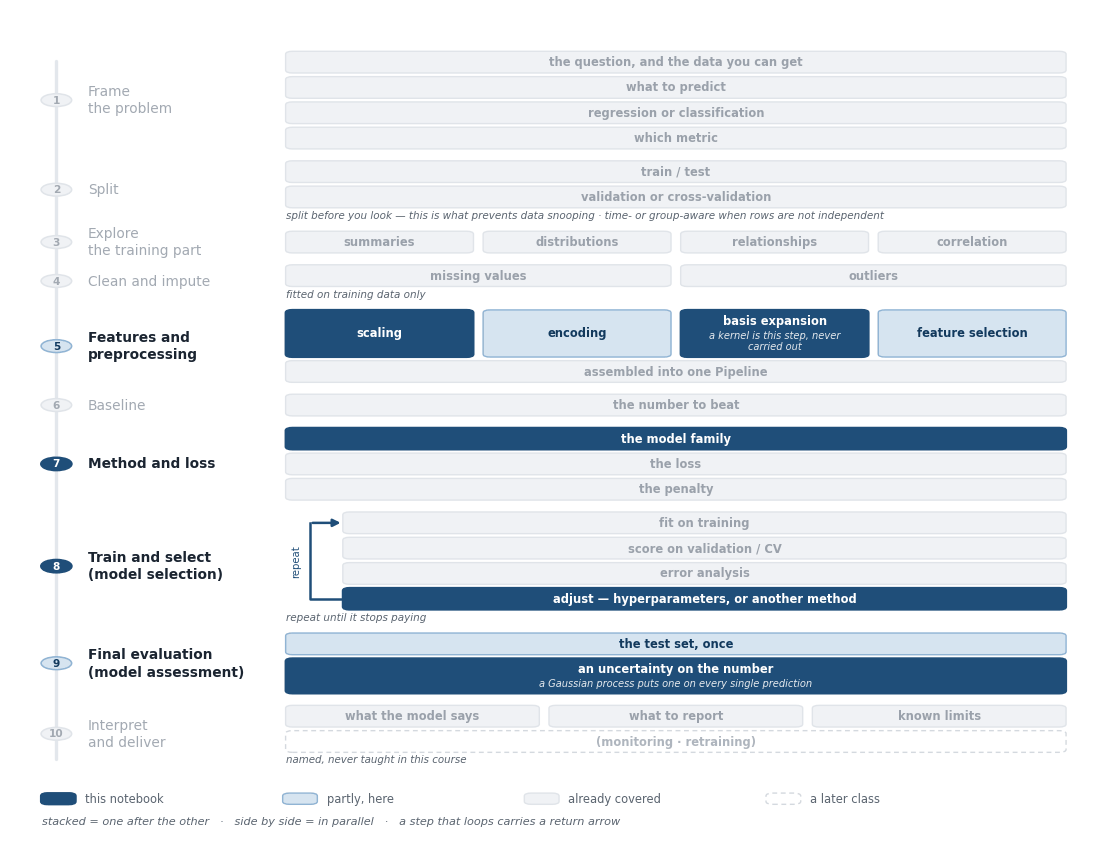

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "done", "3": "done", "4": "done", "5": "part", "5.1": "now",
     "5.3": "now", "5.after": "done", "6": "done", "7.1": "now", "7.2": "done",
     "7.3": "done", "8.1": "done", "8.2": "done", "8.3": "done", "8.4": "now",
     "9": "part", "9.2": "now", "10": "done"},
    notes={"5.3": "a kernel is this step, never carried out",
           "9.2": "a Gaussian process puts one on every single prediction"})
plt.show()

**Step 9.2 is the one to watch.** Every notebook so far has put an uncertainty on a *score* — a
fold spread, a bootstrap interval on the test RMSE. Section 5 puts one on each individual
**prediction**, which is a different object and answers a different question.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_approximation import Nystroem, RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 11,
})

rng = np.random.default_rng(0)

# 1. A richer basis for a linear model

`02A` fitted a spring at rest — hang a mass, measure the extension, recover the stiffness — and its
section 10 made the move this notebook is built on: a model can be **linear in its coefficients**
while being anything at all in the features. Add $\omega^2$ as a column and least squares fits a
parabola without ceasing to be linear regression.

So the question here is never *which model*. It is **which basis**: what set of functions the
columns should be built from, and what goes wrong when that set is chosen badly.

The example is the same spring, driven rather than at rest. Shake the support at a frequency you
control, wait for the transient to die, and record how far the mass swings. Sweep the driving
frequency and the answer traces a **resonance**: small response far from the natural frequency,
large response at it.

$$
A(\omega) \;=\; \frac{A_0}{1 + \big((\omega - \omega_0)/\Gamma\big)^2},
$$

with $\omega_0$ the resonant frequency and $\Gamma$ the linewidth — the same Lorentzian shape as an
absorption line or a Breit–Wigner cross-section. It is a demanding shape for a basis to reproduce,
a sharp peak sitting on two long flat tails, which is exactly why it is used here. The next cell
takes forty measurements across a span of nine linewidths, each good to about 2%.

40 measurements spanning 9.0 linewidths


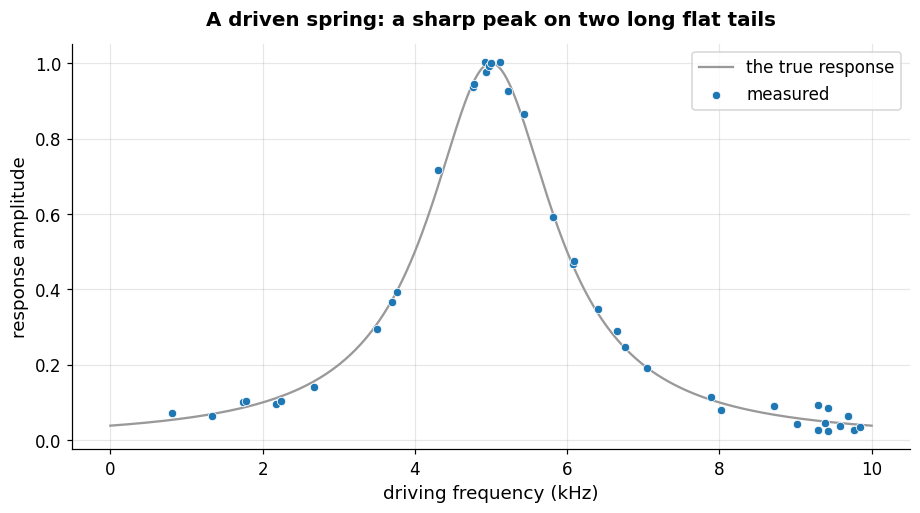

In [ ]:
peak_response, resonance, linewidth = 1.0, 5.0, 1.0      # arbitrary units, kHz, kHz

def lorentzian(frequency):
    """Response amplitude of the driven oscillator, against driving frequency."""
    return peak_response / (1 + ((frequency - resonance) / linewidth) ** 2)

drive_rng = np.random.default_rng(4)                     # this experiment's own seed
driving = np.sort(drive_rng.uniform(0, 10, 40))
response = lorentzian(driving) + drive_rng.normal(0, 0.02, driving.size)

fine = np.linspace(0, 10, 600)                           # a grid for drawing
inside = np.linspace(driving.min(), driving.max(), 500)  # only where measurements exist
rmse = lambda a, b: np.sqrt(np.mean((a - b) ** 2))
detuning = lambda f: (f - resonance) / 5.0               # centred and scaled, for stable powers

print(f"{driving.size} measurements spanning "
      f"{(driving.max() - driving.min()) / linewidth:.1f} linewidths")

plt.figure(figsize=(8.5, 4.8))
plt.plot(fine, lorentzian(fine), color="0.6", linewidth=1.5, label="the true response")
plt.scatter(driving, response, s=30, color="tab:blue", zorder=3, edgecolor="white", linewidth=0.5,
            label="measured")
plt.xlabel("driving frequency (kHz)")
plt.ylabel("response amplitude")
plt.title("A driven spring: a sharp peak on two long flat tails")
plt.legend()
plt.show()

## 1.1 The obvious richer basis: powers of the input

Follow `02A` §10 exactly. In place of the single column $\omega$, use $\omega$, $\omega^2$,
$\omega^3$ and so on up to some degree $D$. Written out, the basis functions and the model are

$$
g_d(\omega) \;=\; \big(\omega - \omega_0\big)^{d},
\qquad\qquad
f(\omega) \;=\; \sum_{d=0}^{D} \alpha_d\, g_d(\omega) .
$$

The code centres on the resonance and divides by half the swept range before taking powers, which
keeps them from overflowing. That rescaling changes the coefficients but not the fitted curve — the
two bases span exactly the same functions — so it is left out of the formula.

Keep that shape in view, because it is the one thing that will not change for the rest of the
notebook: **a sum of basis functions with fitted coefficients.** The model stays linear in its
coefficients, the fit stays ordinary least squares, and only the choice of the $g_d$ is in play. If
a richer basis is what this curve needs, this is the cheapest way to get one.

The next cell fits powers up to seven different degrees, and reports both how well each does and
the largest coefficient it needed to do it.

basis                          RMSE where measured  largest coefficient
powers up to 1                              0.3075                0.398
powers up to 5                              0.1321                 3.52
powers up to 9                              0.0610                 85.2
powers up to 13                             0.0419             1.71e+03
powers up to 19                             0.0651             1.26e+05
powers up to 25                            30.0725             1.24e+08
powers up to 31                         21536.5278             2.93e+11

  features    degree 2    degree 3    degree 4
         1           3           4           5
        10          66         286       1,001
       100       5,151     176,851   4,598,126


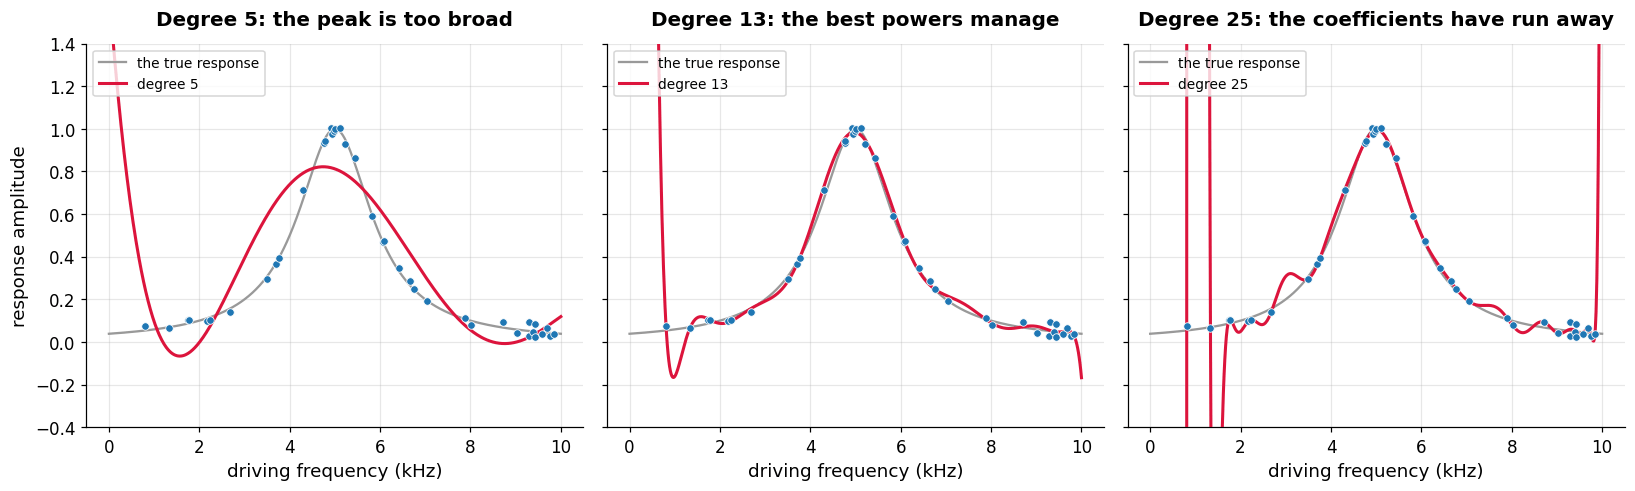

In [ ]:
print(f"{'basis':<28}{'RMSE where measured':>22}{'largest coefficient':>21}")
for degree in (1, 5, 9, 13, 19, 25, 31):
    coefficients = np.polyfit(detuning(driving), response, degree)
    print(f"{'powers up to ' + str(degree):<28}"
          f"{rmse(np.polyval(coefficients, detuning(inside)), lorentzian(inside)):>22.4f}"
          f"{np.abs(coefficients).max():>21.3g}")

from math import comb                      # how many terms a polynomial basis has
print(f"\n{'features':>10}" + "".join(f"{'degree ' + str(d):>12}" for d in (2, 3, 4)))
for features in (1, 10, 100):
    print(f"{features:>10}" + "".join(f"{comb(features + d, d):>12,}" for d in (2, 3, 4)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for axis, degree, verdict in zip(axes, (5, 13, 25),
                                 ("Degree 5: the peak is too broad",
                                  "Degree 13: the best powers manage",
                                  "Degree 25: the coefficients have run away")):
    coefficients = np.polyfit(detuning(driving), response, degree)
    axis.plot(fine, lorentzian(fine), color="0.6", linewidth=1.5, label="the true response")
    axis.scatter(driving, response, s=24, color="tab:blue", zorder=3, edgecolor="white",
                 linewidth=0.5)
    axis.plot(fine, np.polyval(coefficients, detuning(fine)), color="crimson", linewidth=2,
              label=f"degree {degree}")
    axis.set(xlabel="driving frequency (kHz)", title=verdict)
    axis.legend(loc="upper left", fontsize=9)
axes[0].set(ylabel="response amplitude", ylim=(-0.4, 1.4))
plt.show()

Degree 13 is the best of them, reaching 0.042 — about twice the measurement noise, and a genuine
fit. The trouble is everything around it. Degree 5 is three times worse, degree 19 is already
turning back, degree 25 misses by **30** on a curve whose peak is 1, and degree 31 by twenty
thousand. The largest coefficient runs from 3.5 at degree 5 to $3\times10^{11}$ at degree 31: the
fit holds the shape together by cancellation between enormous numbers, and the arithmetic gives out.

Two things are wrong, and only the first is visible in the table.

**The good degree is narrow, and nothing in the data points to it.** You cannot read 13 off the
measurements, the window either side of it is a few degrees wide, and the cost of overshooting is
total rather than gradual.

**In more than one dimension the basis itself explodes.** One input flatters powers: degree 13 is
thirteen columns. With $p$ features the terms up to degree $d$ must include every product, so ten
features give 66 terms at degree 2 and 286 at degree 3, and a hundred features give 5,151 and
176,851. Choosing among them becomes its own problem, and is the subject of the optional notebook
`X1`.

So keep the idea — linear in the coefficients, fitted by least squares, over a basis richer than the
raw features — and change the functions.

## 1.2 What to ask of a basis

The choice is now wide open: any set of functions will serve. That is more freedom than is useful,
so decide first what a good basis ought to look like.

**It should not be wasteful.** Powers are non-zero almost everywhere, so every coefficient buys
flexibility across the whole input space at once. That sounds like a bargain and is not, because
almost all of that space holds no data — and, in more than a couple of dimensions, never will.
A basis fixed before seeing the data has to cover everywhere the model might be asked about; tiling
is even worse than multiplying out, since five positions per feature over ten features is nearly
ten million functions.

Real measurements do not fill their box. They lie on a thin, structured sliver of it, because the
quantities being measured are related to one another. The next cell loads the telescope events that
section 3 will use — ten features, the same data as `05A` — and counts how much of the box they
actually occupy.

14,265 training events, 10 features

 bins per feature   cells in the grid  cells the data visit  share of the grid  test events landing there
                2               1,024                   224          21.8750%                     99.6%
                3              59,049                   668           1.1313%                     97.7%
                5           9,765,625                 2,235           0.0229%                     90.3%
               10      10,000,000,000                 9,052           0.0001%                     52.1%


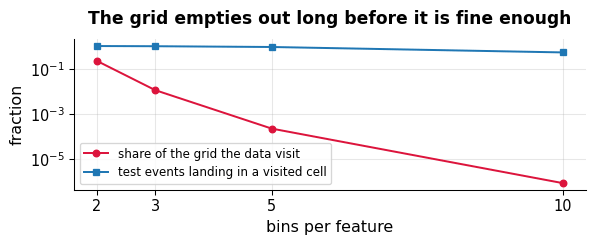

In [ ]:
magic = fetch_openml(data_id=1120, as_frame=True, parser="auto")
X_magic = magic.data.rename(columns=lambda name: name.rstrip(":"))   # OpenML's names end in ":"
y_magic = (magic.target == "g").astype(int)                          # 1 = gamma, 0 = hadron

X_train, X_test, y_train, y_test = train_test_split(X_magic, y_magic, test_size=0.25,
                                                    random_state=0, stratify=y_magic)
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Chop each standardised feature into a few bins, and ask how many of the resulting
# cells the training events actually visit -- and where the unseen test events land.
scaler = StandardScaler().fit(X_train)
train_scaled, test_scaled = scaler.transform(X_train), scaler.transform(X_test)
low, high = train_scaled.min(axis=0), train_scaled.max(axis=0)

def cell_of(points, bins):
    """Which grid cell each event falls into, as a tuple of bin indices."""
    index = np.clip(((points - low) / (high - low) * bins).astype(int), 0, bins - 1)
    return list(map(tuple, index))

features = X_train.shape[1]
print(f"{len(X_train):,} training events, {features} features\n")
print(f"{'bins per feature':>17}{'cells in the grid':>20}{'cells the data visit':>22}"
      f"{'share of the grid':>19}{'test events landing there':>27}")
grid_bins, share_visited, share_landed = [], [], []
for bins in (2, 3, 5, 10):
    visited = set(cell_of(train_scaled, bins))
    landed = sum(c in visited for c in cell_of(test_scaled, bins))
    grid_bins.append(bins)
    share_visited.append(len(visited) / bins ** features)
    share_landed.append(landed / len(test_scaled))
    print(f"{bins:>17}{bins ** features:>20,}{len(visited):>22,}"
          f"{share_visited[-1]:>18.4%}{share_landed[-1]:>26.1%}")

fig, ax = plt.subplots(figsize=(6.4, 2.7), dpi=95)
ax.plot(grid_bins, share_visited, marker="o", ms=5, color="crimson",
        label="share of the grid the data visit")
ax.plot(grid_bins, share_landed, marker="s", ms=5, color="tab:blue",
        label="test events landing in a visited cell")
ax.set(yscale="log", xticks=grid_bins, xlabel="bins per feature", ylabel="fraction",
       title="The grid empties out long before it is fine enough")
ax.legend(fontsize=9)
plt.show()

Take the row with five bins per feature, about the coarsest grid that could describe a curved
boundary at all. There are 9.8 million cells. The 14,265 training events visit **2,235** of them —
**0.02%** of the grid. And the events held back for testing, which the model has never seen, land
in those same 2,235 cells **90%** of the time.

That settles where the basis functions should go. A basis laid out in advance spends 99.98% of
itself on regions that contain no data and will receive almost no predictions. **Put one function
at each measurement instead**, and all of it is spent exactly where the data are — and, as the last
column shows, where the next measurement is going to arrive.

This is the same observation that made nearest neighbours work in `05A` §2, and it is why the price
of the basis below is $n$ rather than something exponential in the number of features. The last row
is a warning rather than a triumph: at ten bins per feature the cells become smaller than the
typical spacing between events, only half the test events find an occupied cell, and *no* method
has enough data to resolve the space at that scale. `06A` returns to this under its own name.

## 1.3 One bump at each measurement

So change the basis. Instead of functions that grow without bound everywhere, use one that is large
near a chosen point and dies away from it — and put one at **each measurement**:

$$
g_i(\omega) \;=\; \exp\!\Big(-\big((\omega - \omega_i)/\ell\big)^2\Big),
\qquad\qquad
f(\omega) \;=\; \sum_{i=1}^{n} \alpha_i\, g_i(\omega) .
$$

Forty measurements, forty bumps, forty coefficients. The **length scale** $\ell$ says how far each
measurement is allowed to speak; everything else is fitted exactly as before, by least squares.
(In the code it is `width` here and `length_scale` from section 4 on, which is scikit-learn's name
for it.) The coefficients $\alpha_i$ are the same $\alpha$ that `05A` §3.2 wrote for the SVM.

RMSE against the true curve             489.65
largest coefficient                   3.67e+14


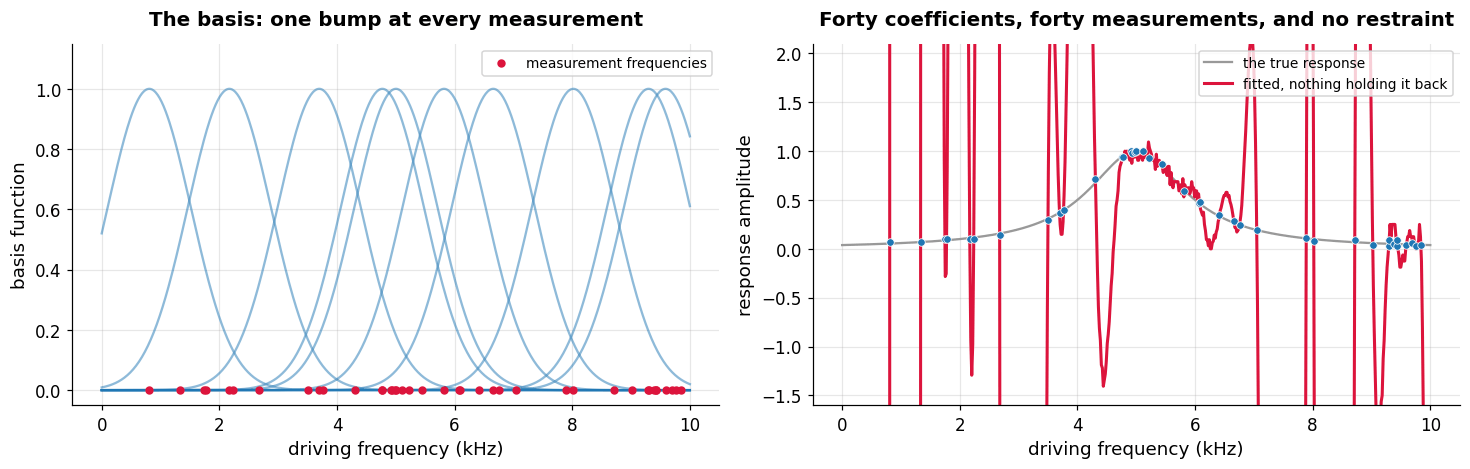

In [ ]:
width = 1.0                                  # the length scale ell, in linewidths

def bumps(at, centres):
    """One Gaussian bump of length scale `width` centred on each entry of `centres`."""
    return np.exp(-((at[:, None] - centres[None, :]) / width) ** 2)

K, K_fine, K_inside = bumps(driving, driving), bumps(fine, driving), bumps(inside, driving)
free = np.linalg.solve(K, response)                  # nothing holding the coefficients down

print(f"{'RMSE against the true curve':<34}{rmse(K_inside @ free, lorentzian(inside)):>12.2f}")
print(f"{'largest coefficient':<34}{np.abs(free).max():>12.3g}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for centre in driving[::4]:
    axes[0].plot(fine, np.exp(-((fine - centre) / width) ** 2), color="tab:blue", alpha=0.5)
axes[0].scatter(driving, np.zeros_like(driving), s=20, color="crimson", zorder=3,
                label="measurement frequencies")
axes[0].set(xlabel="driving frequency (kHz)", ylabel="basis function", ylim=(-0.05, 1.15),
            title="The basis: one bump at every measurement")
axes[0].legend(loc="upper right", fontsize=9)
axes[1].plot(fine, lorentzian(fine), color="0.6", linewidth=1.5, label="the true response")
axes[1].scatter(driving, response, s=24, color="tab:blue", zorder=3, edgecolor="white", linewidth=0.5)
axes[1].plot(fine, K_fine @ free, color="crimson", linewidth=2, label="fitted, nothing holding it back")
axes[1].set(xlabel="driving frequency (kHz)", ylabel="response amplitude", ylim=(-1.6, 2.1),
            title="Forty coefficients, forty measurements, and no restraint")
axes[1].legend(loc="upper right", fontsize=9)
plt.show()

The curve leaves the frame repeatedly. It misses the truth by **490** on a response whose peak is 1,
using coefficients of order $10^{14}$. Forty bumps at forty measurements give the fit exactly enough
freedom to chase every reading — including the noise on it — and it uses every bit of that
freedom.

So the basis is not the problem — the absence of any restraint is. That is the situation `03C` was
written for, and its remedy was not to remove parameters but to **penalise** them.


## 1.4 Too many parameters, and two ways to cut them down

The diagnosis is not subtle: **forty coefficients for forty measurements.** A model with as many
free numbers as it has data can reproduce anything it is shown, and section 1.3 is what that looks
like when it does.

The first thing to try is the obvious one — **use fewer basis functions.** Keep only some of the
bumps, and fit all forty measurements with them.

It is worth being precise about why that helps, because the reason is not that there are now "more
equations than unknowns" — least squares is a minimisation, not a system to be solved, and its
normal equations are square however many measurements there are. The reason is dimensional. The
fitted values at the forty measurements are $A\boldsymbol{\alpha}$, so whatever the coefficients do,
those forty numbers are confined to the column space of $A$ — a subspace of dimension equal to the
number of bumps kept. With all forty bumps that subspace *was* the whole of $\mathbb{R}^{40}$, which
is exactly why the fit could be driven onto every reading. Keep twenty and it is a twenty-
dimensional slice, the readings do not lie in it, the residual cannot be driven to zero, and
section 1.3's interpolation is out of reach by construction.

Which bumps, though? Nothing in the data marks some measurements as better centres than others, so
the simplest answer is to take them **at random**. The next cell does exactly that, at four
different sizes, drawing twenty different subsets at each.

In [ ]:
subset_rng = np.random.default_rng(7)               # its own stream: nothing downstream shifts

print(f"{'bumps kept':>12}{'best RMSE':>12}{'worst RMSE':>12}{'spread across draws':>22}")
for keep in (5, 10, 20, 30):
    reached = []
    for _ in range(20):
        chosen = np.sort(subset_rng.choice(driving.size, keep, replace=False))
        fitted, *_ = np.linalg.lstsq(bumps(driving, driving[chosen]), response, rcond=None)
        reached.append(rmse(bumps(inside, driving[chosen]) @ fitted, lorentzian(inside)))
    reached = np.array(reached)
    print(f"{keep:>12}{reached.min():>12.4f}{reached.max():>12.4f}"
          f"{reached.max() / reached.min():>20.1f}x")

  bumps kept   best RMSE  worst RMSE   spread across draws
           5      0.0500      0.3837                 7.7x
          10      0.0172      0.0735                 4.3x
          20      0.0129      0.0188                 1.5x
          30      0.0310      0.2866                 9.2x


It works. Twenty bumps chosen at random reach **0.0129** at best — the overfit is gone, and nothing
clever was required.

But look at what you now have to decide, and what you cannot control. Twenty is better than thirty,
and nothing in the data told you that: keep too many and the freedom comes back, keep too few and
there is not enough basis left to follow the peak. And at every size the answer depends on **which**
draw you happened to get — a factor of 9 between the best and worst subset of thirty. The model is
hostage to a coin toss.

So this is a real technique rather than a strawman, and section 6 returns to it under the name
**Nyström**, where the motive is speed rather than restraint. As a way of controlling flexibility,
though, it is blunt: the decision is all-or-nothing for each basis function, and it throws away
measurements that cost real money to make.

**The second way out is one this course already has.** `03C` met a model with more parameters than
its data could support and did not delete any of them — it added a penalty to the loss and let every
parameter survive in reduced form. That is the move to make here: keep all forty bumps, and charge
for using them too freely.

`03C` §2 added $\lambda \sum_j \alpha_j^2$ to the loss and shrank the coefficients. The same thing
here reads

$$
\big\lVert \mathbf{y} - K\boldsymbol{\alpha} \big\rVert^2 \;+\; \lambda \sum_i \alpha_i^2 ,
$$

and the next cell shows it working. It then asks a second question, which is the one that matters —
what does $\sum_i \alpha_i^2$ actually measure?

ridge on the coefficients:
  penalty on sum alpha_i^2    RMSE against the truth  largest coefficient
                     1e-06                    0.0124                 4.98
                     0.001                    0.0125                0.164
                       0.1                    0.0152                0.111

                                      sum alpha_i^2  tallest point of the curve
as tall as this basis allows                 1.0000                      2.9906
a middling direction                         1.0000                      0.0011
a direction the basis barely spans           1.0000                      0.0000


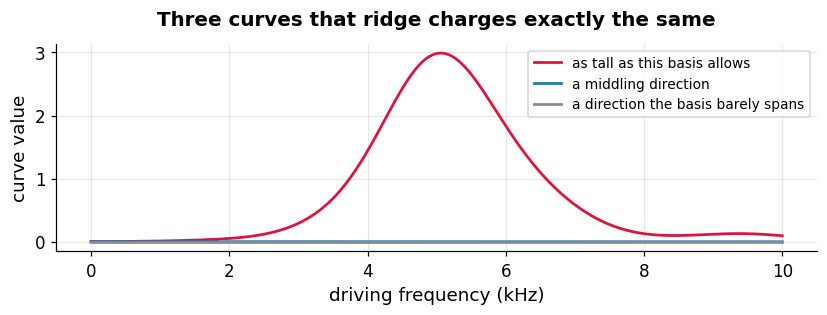

In [ ]:
print("ridge on the coefficients:")
print(f"{'penalty on sum alpha_i^2':>26}{'RMSE against the truth':>26}{'largest coefficient':>21}")
for strength in (1e-6, 1e-3, 1e-1):
    fitted = np.linalg.solve(K.T @ K + strength * np.eye(driving.size), K.T @ response)
    print(f"{strength:>26g}{rmse(K_inside @ fitted, lorentzian(inside)):>26.4f}"
          f"{np.abs(fitted).max():>21.3g}")

# Three coefficient vectors, all with exactly the same sum of squares.
_, directions = np.linalg.eigh(K)

def upright(coefficients):
    """The sign of an eigenvector is arbitrary; draw each curve peak-upwards."""
    curve = K_fine @ coefficients
    return coefficients * np.sign(curve[np.abs(curve).argmax()])

picks = [("as tall as this basis allows", upright(directions[:, -1])),
         ("a middling direction", upright(directions[:, 20])),
         ("a direction the basis barely spans", upright(directions[:, 2]))]
print(f"\n{'':36}{'sum alpha_i^2':>15}{'tallest point of the curve':>28}")
for label, coefficients in picks:
    print(f"{label:<36}{coefficients @ coefficients:>15.4f}"
          f"{np.abs(K_fine @ coefficients).max():>28.4f}")

fig, ax = plt.subplots(figsize=(7.8, 3.0))
for (label, coefficients), colour in zip(picks, ["crimson", "tab:blue", "0.55"]):
    ax.plot(fine, K_fine @ coefficients, color=colour, linewidth=1.8, label=label)
ax.set(xlabel="driving frequency (kHz)", ylabel="curve value",
       title="Three curves that ridge charges exactly the same")
ax.legend(fontsize=9)
plt.show()

Ridge rescues the fit outright: 0.0124 against 490, with the largest coefficient down from $10^{14}$
to about 5. So a penalty is the right instrument.

But the second table is the problem. All three coefficient vectors have $\sum_i \alpha_i^2 = 1$
exactly, so ridge charges them identically — and the curves they produce reach 2.99, 0.0011 and
0.0000. **$\sum_i \alpha_i^2$ is a statement about the list of numbers, not about the curve.** It
can be small for a curve that towers and large for one that barely exists, because the bumps overlap
heavily and the same curve can be written many ways.

## 1.5 A penalty that charges wiggles

What we actually want to discourage is not large coefficients. It is a curve that **wiggles** — that
changes faster, as the driving frequency is swept, than the measurements justify. So build the
penalty out of that directly.

Wiggliness is a statement about frequency content, so write the curve as a superposition. Let
$\hat{f}(\xi)$ be the Fourier transform of the fitted curve,

$$
\hat{f}(\xi) \;=\; \int f(\omega)\, e^{-i\xi\omega}\, d\omega ,
$$

where $\xi$ is conjugate to the driving frequency: **large $\xi$ means the fitted curve varies
rapidly as $\omega$ is swept.** A penalty that charges wiggles is then

$$
\int \mathrm{w}(\xi)\, \big|\hat{f}(\xi)\big|^2\, d\xi ,
$$

with a weight $\mathrm{w}(\xi)$ that grows with $\xi$ — a charge per unit of wiggliness. Setting
$\mathrm{w} = 1$ would charge every frequency equally, which measures the curve's size and not its
roughness; the next cell shows why that is not enough.

In [ ]:
grid = np.linspace(0, 1, 20001)

print(f"{'':26}{'size, integral of f^2':>24}{'roughness, integral of (df/dx)^2':>36}")
for cycles in (1, 5, 20):
    angle = 2 * np.pi * cycles * grid
    height, slope = np.sin(angle), 2 * np.pi * cycles * np.cos(angle)
    print(f"{f'sine, {cycles} cycle(s)':<26}{(height ** 2).mean():>24.4f}"
          f"{(slope ** 2).mean():>36.1f}")

                             size, integral of f^2    roughness, integral of (df/dx)^2
sine, 1 cycle(s)                            0.5000                                19.7
sine, 5 cycle(s)                            0.5000                               493.5
sine, 20 cycle(s)                           0.5000                              7896.1


All three have **the same** size, 0.5000 to four decimals, and the last oscillates twenty times
faster than the first. Charging by size alone cannot tell them apart. The slope-based charge can:
it rises from 19.7 to 7896.1, which is the $\xi^2$ that separates them.

### The penalty, written in the coefficients

Now the step that makes this usable. Our curve is a sum of one bump shifted to each measurement,
$f(\omega) = \sum_i \alpha_i\, k(\omega - \omega_i)$, and a shift only multiplies a transform by a
phase. So

$$
\hat{f}(\xi) \;=\; \hat{k}(\xi) \sum_i \alpha_i\, e^{-i\xi\omega_i} .
$$

Choose the weight to be $\mathrm{w}(\xi) = 1/\hat{k}(\xi)$ and substitute. One factor of $\hat k$
cancels, and what is left is an inverse transform:

$$
\frac{1}{2\pi}\int \frac{\big|\hat f(\xi)\big|^2}{\hat k(\xi)}\, d\xi
\;=\; \frac{1}{2\pi}\int \hat{k}(\xi) \sum_{i,j} \alpha_i \alpha_j\, e^{-i\xi(\omega_i - \omega_j)}\, d\xi
\;=\; \sum_{i,j} \alpha_i \alpha_j\, k(\omega_i - \omega_j)
\;=\; \boldsymbol{\alpha}^\top K \boldsymbol{\alpha} .
$$

**That is the penalty.** A charge on wiggliness, written in Fourier, turns into a quadratic form in
the coefficients whose matrix is $K$ — the same $K$ that already holds the basis functions evaluated
at the measurements. Nothing has to be transformed at run time. The next cell computes both sides.

In [ ]:
alpha = np.linalg.solve(K + 0.01 * np.eye(driving.size), response)   # any coefficients will do

xi = np.linspace(-40, 40, 200001)                     # the conjugate variable, on a fine grid
k_hat = width * np.sqrt(np.pi) * np.exp(-xi ** 2 * width ** 2 / 4)   # transform of the bump
phases = np.exp(-1j * np.outer(xi, driving)) @ alpha                 # sum_i alpha_i exp(-i xi w_i)
integrand = k_hat * np.abs(phases) ** 2               # this is |f_hat|^2 / k_hat, k_hat cancelled

print(f"{'the same penalty, computed two ways':<46}{'value':>13}")
print(f"{'(1/2pi) integral of |f_hat|^2 / k_hat':<46}"
      f"{integrand.sum() * (xi[1] - xi[0]) / (2 * np.pi):>13.8f}")
print(f"{'alpha^T K alpha':<46}{alpha @ K @ alpha:>13.8f}")
print(f"\n{'sum alpha_i^2, the penalty we are replacing':<46}{alpha @ alpha:>13.8f}")

the same penalty, computed two ways                   value
(1/2pi) integral of |f_hat|^2 / k_hat            1.11250570
alpha^T K alpha                                  1.11250570

sum alpha_i^2, the penalty we are replacing     90.10527918


Identical to eight decimals. The two expressions are the same number, so from here on the penalty
can be written $\boldsymbol{\alpha}^\top K \boldsymbol{\alpha}$ and no transform ever appears again.

### Which weight?

One choice was made above and should be stated plainly. Taking $\mathrm{w} = 1/\hat k$ is what made
the cancellation happen, and for the Gaussian bump $k(r) = \exp(-(r/\ell)^2)$ the transform is
$\hat k(\xi) = \ell\sqrt{\pi}\, e^{-\xi^2 \ell^2/4}$, so the weight is

$$
\mathrm{w}(\xi) \;=\; \frac{1}{\ell\sqrt{\pi}}\; e^{\,\xi^2 \ell^2 / 4} .
$$

A curve that wiggles twice as fast is charged not twice as much but exponentially more, and $\ell$
sets the scale at which the charge starts to bite. There are good statistical reasons for choosing
the weight to be the reciprocal of the bump's own transform rather than anything else, and this
course does not go into them.

## 1.6 The overlaps come for free

With the norm chosen, $K$ has to be the matrix of inner products of the basis functions **in that
norm**. Ordinarily that is expensive: one overlap integral per pair, $n(n+1)/2$ of them, over as
many dimensions as the data have, recomputed whenever the measurements change.

The bumps avoid it completely, and this is the property that makes the method usable. Their inner
product is not an integral at all. It is one basis function **evaluated at the other's centre**:

$$
\langle g_i, g_j \rangle \;=\; g_i(\omega_j) \;=\; K_{ij} .
$$

This is the **reproducing property**, and it explains something that has been true since section
1.3 without being remarked on: $K$ does two jobs at once. It is the matrix of basis functions
evaluated at the measurements — the design matrix — *and* the matrix of their overlaps — the
metric. One matrix, one formula, no integrals.

The next cell computes the overlaps the ordinary way, to show what is being skipped.

In [ ]:
fine = np.linspace(-20, 30, 50001)                    # wide enough to hold the whole overlap
step = fine[1] - fine[0]
centres = np.array([4.0, 5.0, 6.5, 9.0])              # four bumps, in the units of section 1
bump_at = lambda c: np.exp(-((fine - c) / width) ** 2)

by_integral = np.array([[(bump_at(a) * bump_at(b)).sum() * step for b in centres]
                        for a in centres])
by_evaluation = bumps(centres, centres)               # no integral at all

print(f"{'bumps':>12}{'gap':>7}{'overlap by integral':>22}{'K, by evaluation':>20}")
for j in (1, 2, 3):
    print(f"{'1 and ' + str(j + 1):>12}{abs(centres[0] - centres[j]):>7.1f}"
          f"{by_integral[0, j]:>22.5f}{by_evaluation[0, j]:>20.5f}")

print(f"\nthe integral's bump is wider. Divide it by w*sqrt(pi/2) = "
      f"{width * np.sqrt(np.pi / 2):.4f} and it returns")
print(f"   {np.array2string(by_integral[0, 1:] / (width * np.sqrt(np.pi / 2)), precision=6)}")
print(f"against the square roots of K's entries:")
print(f"   {np.array2string(np.sqrt(by_evaluation[0, 1:]), precision=6)}")

       bumps    gap   overlap by integral    K, by evaluation
     1 and 2    1.0               0.76017             0.36788
     1 and 3    2.5               0.05507             0.00193
     1 and 4    5.0               0.00000             0.00000

the integral's bump is wider. Divide it by w*sqrt(pi/2) = 1.2533 and it returns
   [6.065307e-01 4.393693e-02 3.726653e-06]
against the square roots of K's entries:
   [6.065307e-01 4.393693e-02 3.726653e-06]


The two matrices are genuinely different, not rescaled versions of one another. At a gap of one
linewidth the integral gives 0.76017 where $K$ gives 0.36788, and the discrepancy grows with the
gap, because the integral of two Gaussians is a Gaussian $\sqrt{2}$ times wider — dividing it by
$w\sqrt{\pi/2}$ returns the **square roots** of $K$'s entries, exactly.

So $\int f^2$ would have given a different penalty matrix, and a worse one, for the reason section
1.5 showed. The bumps were not chosen because a Gaussian is a pleasant shape. They were chosen
because there exists an inner product in which their overlaps are their own values, and it is the
inner product that charges wiggles. **Choosing the basis and choosing the norm are one act.**

## 1.7 The whole fit in one line


With the penalty settled, the fit has a closed form, and it is worth deriving rather than quoting —
because section 5 hands back this same expression from an entirely different direction.

Collect the fitted values at the $n$ measured frequencies into a vector. Since
$f(\omega_i) = \sum_j \alpha_j g_j(\omega_i)$ and $K_{ij} = g_j(\omega_i)$, that is a matrix product:

$$
\bar{\mathbf{f}} \;=\; K\boldsymbol{\alpha} ,
\qquad\text{so the fit minimises}\qquad
\big\lVert \mathbf{y} - K\boldsymbol{\alpha} \big\rVert^2
\;+\; \lambda\, \boldsymbol{\alpha}^\top K \boldsymbol{\alpha} .
$$

Differentiate with respect to $\boldsymbol{\alpha}$ and set the result to zero. Using $K^\top = K$,

$$
-2K\big(\mathbf{y} - K\boldsymbol{\alpha}\big) \;+\; 2\lambda K \boldsymbol{\alpha} \;=\; 0
\qquad\Longrightarrow\qquad
K\Big[\big(K + \lambda I\big)\boldsymbol{\alpha} - \mathbf{y}\Big] \;=\; 0 ,
$$

so whenever $K$ can be inverted,

$$
\boxed{\;\boldsymbol{\alpha} \;=\; \big(K + \lambda I\big)^{-1}\mathbf{y}\;}
$$

Two things fall straight out of that line.

**Set $\lambda = 0$ and the disaster of section 1.3 is not bad luck, it is arithmetic.** Then
$\boldsymbol{\alpha} = K^{-1}\mathbf{y}$, so the fitted values are
$\bar{\mathbf{f}} = K K^{-1}\mathbf{y} = \mathbf{y}$ — the curve reproduces *every* measurement
exactly, noise included, because it has exactly enough freedom to do so. Unpenalised, this basis
interpolates by construction, and section 1.3 drew the result.

**And the entire effect of the penalty is to add $\lambda$ to the diagonal before inverting.**
Nothing else in the expression changes. That is the whole of regularisation here, and it is why the
sweep in the cell above was a sweep over a single number.

Finally, the prediction *anywhere else*. Writing $\mathbf{k}_*$ for the vector of the $n$ bumps
evaluated at a new frequency $\omega_*$, the model is $f(\omega_*) = \sum_i \alpha_i g_i(\omega_*)
= \mathbf{k}_*^\top \boldsymbol{\alpha}$, so

$$
f(\omega_*) \;=\; \mathbf{k}_*^{\top}\big(K + \lambda I\big)^{-1}\mathbf{y} .
$$

**Keep that expression in view.** Section 5 arrives at it again, starting from probability instead
of from a penalty, and the only thing that changes is what $\lambda$ is called.

## 1.8 What this says about features you build by hand

Section 1.2 argued against a *fixed grid* of basis functions. There is a second way to enlarge a
basis by hand, and it fails for a different reason, worth having because it is the one people
actually use: add features, as `02A` §10 did — a square, a product of two columns — and fall back
on $\sum_j \alpha_j^2$ after standardising every column.

Standardising sets each column to unit variance. In the language of section 1.5, it equalises
$\int f^2$: it makes the basis functions the same **size**. It says nothing whatever about their
**roughness**, and section 1.5 was the demonstration that those are different measurements.

In [ ]:
axis = np.linspace(-12, 12, 200001)                    # integrate against a standard normal
density = np.exp(-axis ** 2 / 2) / np.sqrt(2 * np.pi)
average = lambda values: (values * density).sum() * (axis[1] - axis[0])

print(f"{'basis function':<26}{'size, average of f^2':>23}{'roughness, average of (df/dx)^2':>34}")
for power in (1, 3, 5):
    values, slopes = axis ** power, power * axis ** (power - 1)
    scale = np.sqrt(average(values ** 2))              # exactly what standardising does
    print(f"{f'x^{power}, standardised':<26}{average((values / scale) ** 2):>23.3f}"
          f"{average((slopes / scale) ** 2):>34.3f}")

basis function               size, average of f^2   roughness, average of (df/dx)^2
x^1, standardised                           1.000                             1.000
x^3, standardised                           1.000                             1.800
x^5, standardised                           1.000                             2.778


Every row has the same size, 1.000, because that is what standardising is for. The roughness is not
equal at all: the cubic is **1.800** times rougher than the linear term and the quintic
**2.778** times, at identical amplitude.

So $\sum_j \alpha_j^2$ on a hand-built polynomial basis is an **amplitude** penalty, not a smoothness
penalty. It is justified when every basis function is equally smooth — which is true of a purely
linear model, and is the reason `03C`'s ridge was on firm ground — and it stops being true the
moment a power is added. Nothing warns you; the fit simply under-penalises the terms that wiggle
most.

> **This is what the basis of section 1.2 buys, and it is not flexibility.** It is a consistent
> accounting of roughness across a basis whose members are not equally smooth, supplied for every
> basis function at once, with no per-feature decision to make. Engineering features by hand and
> standardising them silently asserts that they are all equally smooth.

# 2. What you have just built is a kernel method

Nothing in section 1 mentioned kernels. A basis of bumps was chosen, its coefficients were fitted
by least squares, and a penalty was derived in the metric that basis forces. That is the whole of
kernel regression, and **nothing below adds to it** — this section only attaches the standard
names, states which functions are allowed, and lists the two you will actually use.

The matrix $K$ is the **kernel matrix**. The function behind it,
$K(\omega, \omega') = \exp(-((\omega-\omega')/\ell)^2)$, is the **kernel** — and written with
$\gamma = 1/\ell^2$ it is the **radial basis function** kernel that the rest of the course uses. The
basis functions $g_i$ are its **kernel sections**, one per measurement.

## 2.1 The same statement, with a feature space

There is a second way to say what section 1 derived. It is the historical route, it is where the
phrase *kernel trick* comes from, and its real job is to supply the admissibility test of section
2.2.

Suppose the kernel can be written as a dot product of **feature vectors**,

$$
K(\mathbf{x}, \mathbf{x}') \;=\; \boldsymbol{\phi}(\mathbf{x}) \cdot \boldsymbol{\phi}(\mathbf{x}') ,
$$

for some map $\boldsymbol{\phi}$. Then the fitted function is a plain linear model in those
coordinates, $f(\mathbf{x}) = \mathbf{w}\cdot\boldsymbol{\phi}(\mathbf{x})$ with
$\mathbf{w} = \sum_i \alpha_i \boldsymbol{\phi}(\mathbf{x}_i)$, and

$$
\lVert\mathbf{w}\rVert^2 \;=\; \sum_i\sum_j \alpha_i \alpha_j\, \boldsymbol{\phi}(\mathbf{x}_i)\cdot
\boldsymbol{\phi}(\mathbf{x}_j) \;=\; \boldsymbol{\alpha}^\top K \boldsymbol{\alpha} .
$$

The penalty of section 1.4 is therefore an **ordinary ridge penalty on an ordinary linear model**,
in coordinates nobody constructs — which is why `C` in an SVM, $\lambda$ in this fit and the noise
level in section 5 all turn out to be the same number in different clothing.

The cell below takes the degree-2 polynomial kernel, $(1 + \mathbf{x}\cdot\mathbf{x}')^2$, where
$\boldsymbol{\phi}$ is short enough to write down, and checks both halves.

In [ ]:
def expansion(x):
    """Every polynomial term up to degree 2, for a sample with two features."""
    return np.array([1, np.sqrt(2) * x[0], np.sqrt(2) * x[1],
                     x[0] ** 2, np.sqrt(2) * x[0] * x[1], x[1] ** 2])

pair = rng.normal(size=(2, 2))
built = expansion(pair[0]) @ expansion(pair[1])        # build the six features, then dot them
from_kernel = (1 + pair[0] @ pair[1]) ** 2             # never build them
print(f"phi(x) . phi(x')      : {built:.12f}")
print(f"(1 + x . x')^2        : {from_kernel:.12f}")
print(f"difference            : {abs(built - from_kernel):.1e}")

sample = rng.normal(size=(6, 2))
K_poly = (1 + sample @ sample.T) ** 2
Phi = np.array([expansion(x) for x in sample])
print(f"\nis K the matrix of dot products of the expansions?  "
      f"max difference {np.abs(K_poly - Phi @ Phi.T).max():.1e}")
coefficients = rng.normal(size=6)
w = Phi.T @ coefficients
print(f"||w||^2 in the six-dimensional space : {w @ w:.10f}")
print(f"a^T K a                              : {coefficients @ K_poly @ coefficients:.10f}")

phi(x) . phi(x')      : 1.137769242607
(1 + x . x')^2        : 1.137769242607
difference            : 0.0e+00

is K the matrix of dot products of the expansions?  max difference 7.1e-15
||w||^2 in the six-dimensional space : 28.9954820663
a^T K a                              : 28.9954820663


Both hold exactly. The kernel returns the dot product of two six-dimensional expansions without
building either, and the penalty is the squared length of the weight vector in that space.

Two cautions, because this framing is easy to over-read. It is a statement that a computation can
be **skipped**; it is not the source of the flexibility, which came from putting one basis function
at each measurement back in section 1.2. And nothing in section 1 needed it — the penalty was
derived there, in the function space, without any feature space at all. What it does give is the
next subsection.

## 2.2 Not every function will do

Since $K$ has to be a matrix of dot products, it cannot be arbitrary. It must be **symmetric** and
**positive semi-definite**: for any set of points, $K_{ij}$ must have no negative eigenvalues.
Equivalently — and this is the version section 1.6 needs — positive semi-definiteness is exactly
the condition under which an inner product with the reproducing property exists at all.

This is not a formality, and the obvious naive choice fails it. `05A` §2 predicted from the
neighbours inside a fixed radius, which is the same sum with a **step** in place of the bump:
$K(\omega, \omega') = 1$ if the two are within $r$ of each other and $0$ otherwise.

In [ ]:
points = rng.uniform(0, 10, 60)[:, None]
gaps = np.abs(points - points.T)

print(f"{'window':<34}{'smallest eigenvalue of K':>26}")
for radius in (0.5, 1.5, 3.0):
    step_K = (gaps < radius).astype(float)
    print(f"{'step, everything within ' + str(radius):<34}"
          f"{np.linalg.eigvalsh(step_K).min():>26.3f}")
for scale in (0.5, 1.5, 3.0):
    print(f"{'smooth bump of width ' + str(scale):<34}"
          f"{np.linalg.eigvalsh(np.exp(-(gaps / scale) ** 2)).min():>26.3e}")

window                              smallest eigenvalue of K
step, everything within 0.5                           -1.772
step, everything within 1.5                           -4.173
step, everything within 3.0                           -6.343
smooth bump of width 0.5                           8.748e-16
smooth bump of width 1.5                          -2.875e-15
smooth bump of width 3.0                          -5.779e-15


The step window has strongly negative eigenvalues; the smooth bump does not. So averaging over a
fixed radius is a perfectly good thing to do — it is what `05A` §2 did, and it worked — but it
cannot be given **fitted** weights, because no inner product reproduces those overlaps, so there is
no length to penalise and no convex problem to solve. Smoothing the window is what makes the step
from averaging to fitting legal.

## 2.3 The two kernels in use

In practice you will not invent one. Two cover almost everything.

The **polynomial kernel** of degree $d$,

$$
K(\mathbf{x}, \mathbf{x}') \;=\; \big(1 + \mathbf{x}\cdot\mathbf{x}'\big)^d ,
$$

whose expansion is every product of features up to degree $d$ — a finite list, which section 2.1
wrote out for $d = 2$. Its unequal coefficients there, the $\sqrt{2}$s, are section 1.8's point
made by the kernel itself: it does not treat the monomials as interchangeable.

The **radial basis function**, or **RBF**, kernel,

$$
K(\mathbf{x}, \mathbf{x}') \;=\; \exp\!\big(-\gamma \, \| \mathbf{x}-\mathbf{x}' \|^2 \big) ,
$$

whose expansion cannot be written out at any length. It is section 1's bump, with $\gamma = 1/\ell^2$
and the one-dimensional gap replaced by the Euclidean distance of `05A` §1. It turns a distance
into a **similarity**: 1 when two samples coincide, falling smoothly to 0 as they separate.
$\gamma$ is the width dial of section 1.2, inverted — large $\gamma$ is a narrow bump, and so a
short reach for each training point.

# 3. The same trick, for a boundary

Everything so far fitted a number. The step to classification needs no new machinery at all: the
`05A` support vector machine also touches its samples only through dot products, so the same
substitution applies to it unchanged.

`02B` §9 built two classes as concentric rings — one in a central disc, the other in a ring around
it — and fitted a logistic regression. The result was the sharpest failure in the course: the model
did not draw a bad line, it found that **no** line helps, set both coefficients to within a few
hundredths of zero, and predicted a single class everywhere. The rings are rebuilt below, with
three flat-boundary models and one tree.

In [ ]:
rings_rng = np.random.default_rng(0)                    # same construction, and same seed, as 02B section 9
n_points = 300
radius = rings_rng.uniform(0, 1, n_points)
angle = rings_rng.uniform(0, 2 * np.pi, n_points)

X_rings = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
y_rings = (radius < 0.5).astype(int)                    # inner disc is class 1

contenders = [("logistic regression (02B)", LogisticRegression()),
              ("linear SVM (05A)", SVC(kernel="linear")),
              ("decision tree, depth 5 (04A)", DecisionTreeClassifier(max_depth=5, random_state=0))]

print(f"{'':30}{'training accuracy':>19}")
for name, model in contenders:
    print(f"{name:30}{model.fit(X_rings, y_rings).score(X_rings, y_rings):>19.3f}")
print(f"\nmajority class alone: {max(y_rings.mean(), 1 - y_rings.mean()):.3f}")

                                training accuracy
logistic regression (02B)                   0.550
linear SVM (05A)                            0.550
decision tree, depth 5 (04A)                0.980

majority class alone: 0.550


The two flat boundaries score 0.550, exactly the majority class — they have learned nothing. The
tree reaches 0.980 by stacking axis-aligned cuts into a staircase, which is `04A` §11.2's picture,
and `04A` §11.2 promised that the staircase is an approximation to a model whose boundary is
genuinely curved. That model is one argument away.

## 3.1 The rings, solved

`SVC(kernel="linear")` becomes `SVC()`, whose default kernel is RBF. Nothing else changes.

SVM, linear kernel : 0.550
SVM, RBF kernel    : 0.987
support vectors    : 68 of 300


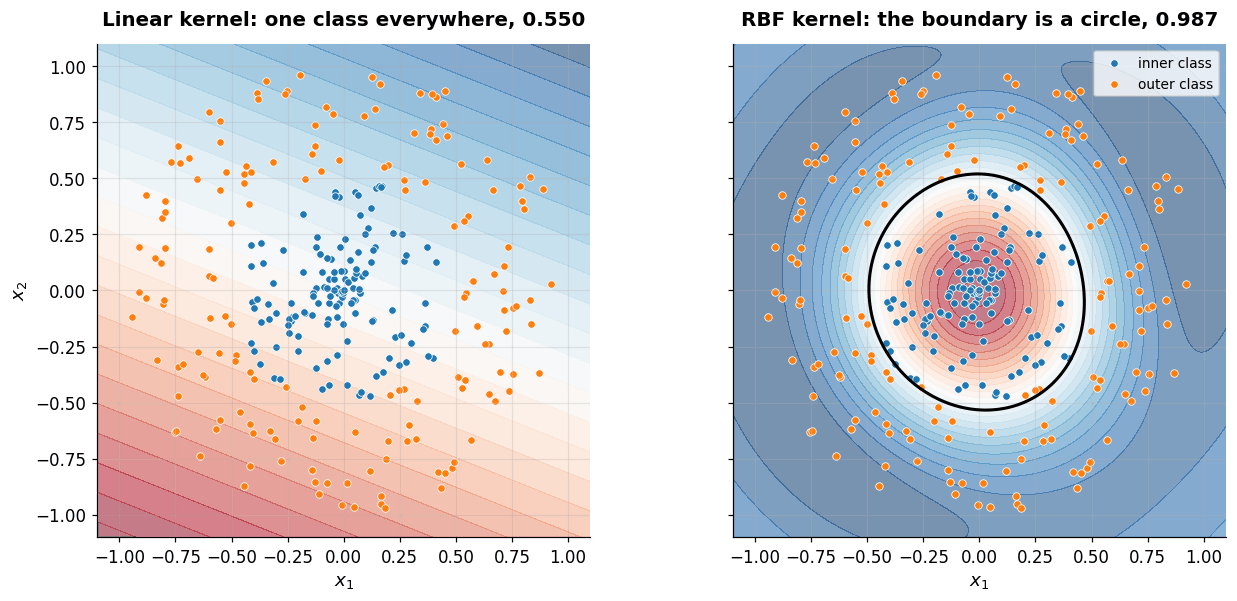

In [ ]:
rings_rbf = SVC().fit(X_rings, y_rings)                       # kernel="rbf" is the default
rings_linear = SVC(kernel="linear").fit(X_rings, y_rings)

print(f"SVM, linear kernel : {rings_linear.score(X_rings, y_rings):.3f}")
print(f"SVM, RBF kernel    : {rings_rbf.score(X_rings, y_rings):.3f}")
print(f"support vectors    : {rings_rbf.n_support_.sum()} of {n_points}")

mesh_x, mesh_y = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
mesh = np.column_stack([mesh_x.ravel(), mesh_y.ravel()])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharey=True)
for axis, model, title in [(axes[0], rings_linear, "Linear kernel: one class everywhere, 0.550"),
                           (axes[1], rings_rbf, "RBF kernel: the boundary is a circle, 0.987")]:
    scores = model.decision_function(mesh).reshape(mesh_x.shape)
    axis.contourf(mesh_x, mesh_y, scores, levels=25, cmap="RdBu_r", alpha=0.55)
    axis.contour(mesh_x, mesh_y, scores, levels=[0], colors="black", linewidths=2)
    for value, name in [(1, "inner class"), (0, "outer class")]:
        mask = y_rings == value
        axis.scatter(X_rings[mask, 0], X_rings[mask, 1], s=24, edgecolor="white",
                     linewidth=0.5, label=name)
    axis.set(xlabel="$x_1$", title=title)
    axis.set_aspect("equal")
axes[0].set_ylabel("$x_2$")
axes[1].legend(loc="upper right", fontsize=9)
plt.show()

0.987 — against 0.550 for the same machine with a flat boundary, and 0.980 for the tree's
staircase. Nobody told the model that the classes were arranged in rings, and
no expanded design matrix was ever constructed.

This is `04A` §11.2's promise discharged. The tree reached 0.980 by cutting a staircase; the RBF
SVM reaches 0.987 with a boundary that is simply round, because round is what the data are.

## 3.2 $\gamma$ and `C` are two dials, and one of them overfits fast

The next cell sweeps $\gamma$ over four orders of magnitude on 4,000 telescope events, holding
`C` fixed, and reports the training ROC AUC beside the cross-validated one.

1. Which way will the **training** score move as $\gamma$ grows?
2. Which way will the **cross-validated** score move?
3. The number of support vectors is printed too. `05A` §3.4 found that samples inside the margin
   are support vectors — so what should that count do at the two ends of the sweep?

**Think about your answer before running this cell.**

In [ ]:
subset = slice(0, 4000)                       # a quarter of the training events, to keep this quick
print(f"{'gamma':>8}{'training ROC AUC':>19}{'cross-validated':>18}{'support vectors':>18}")
for gamma_value in [0.001, 0.01, 0.1, 1.0, 10.0]:
    machine = make_pipeline(StandardScaler(), SVC(gamma=gamma_value, C=10))
    validated = cross_val_score(machine, X_train[subset], y_train[subset], cv=folds,
                                scoring="roc_auc", n_jobs=-1)
    machine.fit(X_train[subset], y_train[subset])
    trained = roc_auc_score(y_train[subset], machine.decision_function(X_train[subset]))
    print(f"{gamma_value:>8}{trained:>19.4f}{validated.mean():>18.4f}{machine[-1].n_support_.sum():>18}")

The output, since it is not stored in the notebook: the training score climbs from 0.8535 at
$\gamma = 0.001$ to **1.0000** at $\gamma = 10$ — a perfect score on its own training events. The
cross-validated score does something quite different. It rises to 0.9105 at $\gamma = 0.1$ and
then **falls back to 0.8142**, worse than the linear SVM of `05A`. The support-vector count traces
a U: 2028 at the stiffest setting, 1376 at the best one, and 3998 at the loosest — which is every
one of the 4,000 events, each one carrying its own little bump.

This is the bias–variance picture of `03B` in its purest form, and the gap between the two columns
is the diagnosis: a training score of 1.0000 beside a cross-validated 0.8142 is a model that has
memorised. `05A`'s `C` sweep could not produce this, because a straight line has too little
freedom to memorise anything. With a kernel, the model has as much freedom as you ask for.

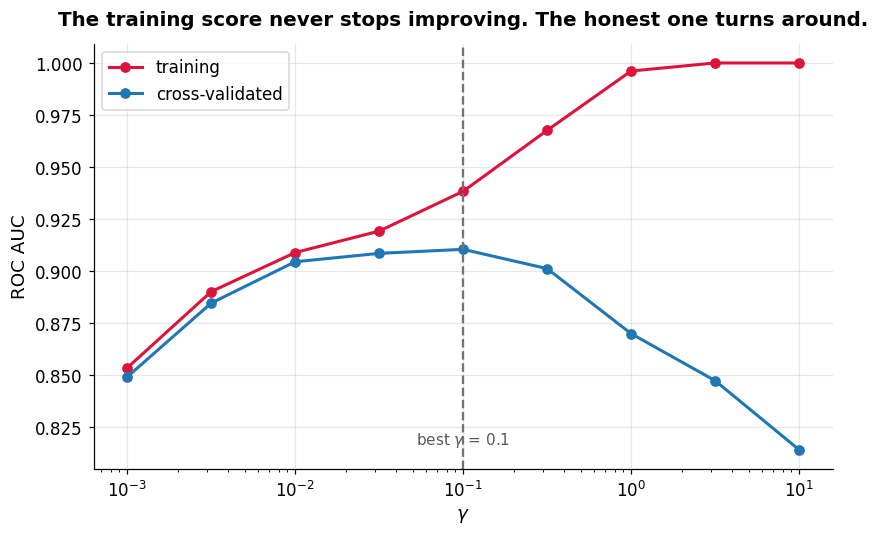

In [ ]:
gammas = np.logspace(-3, 1, 9)
train_curve, validated_curve = [], []
for gamma_value in gammas:
    machine = make_pipeline(StandardScaler(), SVC(gamma=gamma_value, C=10))
    validated_curve.append(cross_val_score(machine, X_train[subset], y_train[subset], cv=folds,
                                           scoring="roc_auc", n_jobs=-1).mean())
    machine.fit(X_train[subset], y_train[subset])
    train_curve.append(roc_auc_score(y_train[subset], machine.decision_function(X_train[subset])))

best = gammas[int(np.argmax(validated_curve))]
plt.figure(figsize=(7.8, 5))
plt.semilogx(gammas, train_curve, "o-", color="crimson", linewidth=2, label="training")
plt.semilogx(gammas, validated_curve, "o-", color="tab:blue", linewidth=2, label="cross-validated")
plt.axvline(best, color="0.45", linestyle="--", linewidth=1.5)
plt.annotate(f"best $\\gamma$ = {best:.3g}", xy=(best, min(validated_curve)), fontsize=10,
             color="0.35", ha="center", va="bottom")
plt.xlabel("$\\gamma$")
plt.ylabel("ROC AUC")
plt.title("The training score never stops improving. The honest one turns around.")
plt.legend()
plt.show()

**And what about `C`?** Everything above held it fixed at 10, so the section has so far shown one
dial and named two. The next cell sweeps `C` twice: once at the $\gamma$ that the curve above
chose, and once at a $\gamma$ ten times too large.


C swept at the gamma the sweep above chose (gamma = 0.1):
       C   training ROC AUC   cross-validated   support vectors


    0.01             0.8658            0.8627              2879


     0.1             0.9031            0.8956              2034


       1             0.9205            0.9094              1605


      10             0.9383            0.9105              1376


...

     0.1             1.0000            0.8174              4000


       1             1.0000            0.8174              4000


      10             1.0000            0.8142              3998


     100             1.0000            0.8142              3998


    1000             1.0000            0.8142              3998


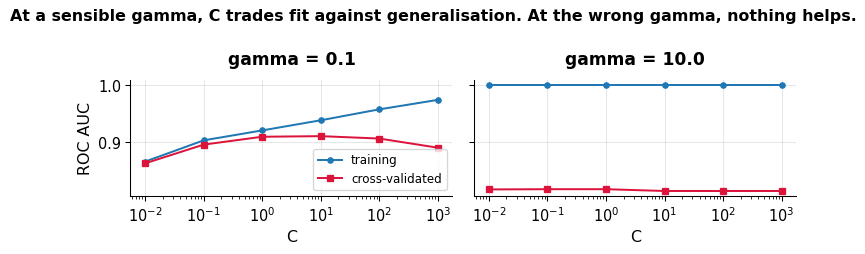

In [ ]:
costs = (0.01, 0.1, 1, 10, 100, 1000)
curves = {}
for gamma_value, verdict in [(0.1, "at the gamma the sweep above chose"),
                             (10.0, "at a gamma ten times too large")]:
    print(f"\nC swept {verdict} (gamma = {gamma_value}):")
    print(f"{'C':>8}{'training ROC AUC':>19}{'cross-validated':>18}{'support vectors':>18}")
    curves[gamma_value] = ([], [])
    for cost in costs:
        machine = make_pipeline(StandardScaler(), SVC(gamma=gamma_value, C=cost))
        validated = cross_val_score(machine, X_train[subset], y_train[subset], cv=folds,
                                    scoring="roc_auc", n_jobs=-1).mean()
        machine.fit(X_train[subset], y_train[subset])
        trained = roc_auc_score(y_train[subset], machine.decision_function(X_train[subset]))
        curves[gamma_value][0].append(trained)
        curves[gamma_value][1].append(validated)
        print(f"{cost:>8}{trained:>19.4f}{validated:>18.4f}{machine[-1].n_support_.sum():>18}")

fig, axes = plt.subplots(1, 2, figsize=(8.0, 2.7), dpi=95, sharey=True)
for ax, (gamma_value, (trained, validated)) in zip(axes, curves.items()):
    ax.plot(costs, trained, marker="o", ms=4, color="tab:blue", label="training")
    ax.plot(costs, validated, marker="s", ms=4, color="crimson", label="cross-validated")
    ax.set(xscale="log", xlabel="C", title=f"gamma = {gamma_value}")
axes[0].set_ylabel("ROC AUC")
axes[0].legend(fontsize=9, loc="lower right")
fig.suptitle("At a sensible gamma, C trades fit against generalisation. At the wrong gamma, "
             "nothing helps.", fontsize=12, fontweight="bold")
plt.show()

**At a sensible $\gamma$, `C` behaves exactly like the penalty it is.** The cross-validated score
climbs from 0.8627 to 0.9105 and then falls back to 0.8902, a swing of about 0.05 — a proper
bias–variance curve, with the training score rising all the way from 0.8658 to 0.9742 and the
support-vector count falling from 2879 to 1202 as the fit is allowed to commit to fewer, closer
points. This is `05A` §3.3's dial doing what it did there.

**At the wrong $\gamma$, `C` can do nothing at all.** Look at the second table. The training score
is **1.0000 for every value of `C`**, across five orders of magnitude, and the cross-validated
score never leaves the neighbourhood of 0.817. The support-vector column says why: all **4000 of
the 4000** events are support vectors at every setting. With bumps that narrow each training event
sits alone in its own tiny region, every one of them is needed to describe the fit, and no penalty
on $\lVert\mathbf{w}\rVert^2$ can make the model see past them. The overfitting is built into the
*basis*, and the penalty is applied to the coefficients.

> **Two dials, and they are not interchangeable.** $\gamma$ chooses the basis; `C` chooses how hard
> the fit is allowed to lean on it. A good `C` cannot rescue a bad $\gamma$, but a bad `C` will
> certainly waste a good one — which is why section 7 searches the pair together rather than one
> after the other.

## 3.3 Back to the telescope

`05A` §4.1 left a table with three tiers on these events: the two flat-boundary models at 0.833
and 0.837, nearest neighbours at 0.900, and the tree ensembles at about 0.935. The linear SVM was
at the bottom. Refit it on the full training set with an RBF kernel and a tuned `C`.

                                               cross-validated ROC AUC


linear SVM, C = 1 (05A section 4.1)                       0.8328 +/- 0.0056


RBF kernel, default C = 1                                 0.9154 +/- 0.0041


RBF kernel, C = 10                                        0.9236 +/- 0.0049

for reference, from 05A section 4.1:
31 nearest neighbours                                     0.9000
random forest, 300 trees (04B)                            0.9350


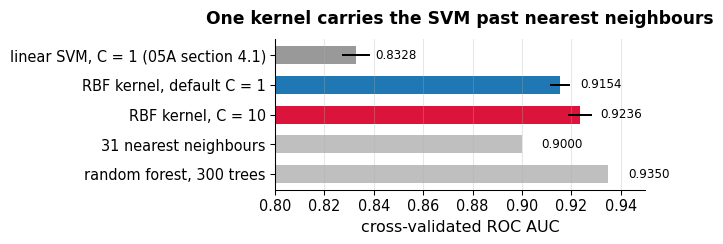

In [ ]:
bars = []
print(f"{'':44}{'cross-validated ROC AUC':>26}")
for name, machine in [("linear SVM, C = 1 (05A section 4.1)", SVC(kernel="linear", C=1)),
                      ("RBF kernel, default C = 1", SVC()),
                      ("RBF kernel, C = 10", SVC(C=10))]:
    scores = cross_val_score(make_pipeline(StandardScaler(), machine), X_train, y_train,
                             cv=folds, scoring="roc_auc", n_jobs=-1)
    bars.append((name, scores.mean(), scores.std()))
    print(f"{name:44}{scores.mean():>20.4f} +/- {scores.std():.4f}")

print("\nfor reference, from 05A section 4.1:")
print(f"{'31 nearest neighbours':44}{0.900:>20.4f}")
print(f"{'random forest, 300 trees (04B)':44}{0.935:>20.4f}")

labels = [b[0] for b in bars] + ["31 nearest neighbours", "random forest, 300 trees"]
values = [b[1] for b in bars] + [0.900, 0.935]
spreads = [b[2] for b in bars] + [0.0, 0.0]
colours = ["0.6", "tab:blue", "crimson", "0.75", "0.75"]
fig, ax = plt.subplots(figsize=(7.2, 2.7), dpi=95)
ax.barh(labels, values, xerr=spreads, color=colours, height=0.6)
ax.set(xlim=(0.80, 0.95), xlabel="cross-validated ROC AUC",
       title="One kernel carries the SVM past nearest neighbours")
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
for y, v in enumerate(values):
    ax.text(v + 0.008, y, f"{v:.4f}", va="center", fontsize=9)
plt.show()

0.8328 to 0.9236. One argument, and the SVM has crossed two tiers of `05A`'s table: past nearest
neighbours at 0.900 and within 0.012 of the random forest, which is the strongest model the course
has fitted to these events. The boundary really was the problem, exactly as `05A` §5 diagnosed,
and `C` really could not fix it.

**A caution, and it is the honest half of the result.** This is the best-case advertisement for
kernels: ten continuous features on a common physical footing, 14,265 events, and a genuinely
curved boundary. Section 6 shows what the same model costs at ten times the sample size, and
broad benchmarks place the two families closer than this single table suggests: across a hundred
or so datasets, random forests come out the strongest family overall, with RBF-kernel SVMs
immediately behind them.

## 3.4 A kernel built from a distance must be given scaled features

`05A` §1 showed that an unscaled Euclidean distance on these events is dominated by four
millimetre-valued features, while three others — including the total light — contribute less than
0.01% of it. The RBF kernel has that same distance inside it, so it inherits that same defect, and
`StandardScaler` is not an optional tidiness.

In [ ]:
for label, machine in [("RBF kernel, raw features", SVC(C=10)),
                       ("RBF kernel, inside a StandardScaler", make_pipeline(StandardScaler(), SVC(C=10)))]:
    scores = cross_val_score(machine, X_train, y_train, cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{label:38}{scores.mean():>10.4f} +/- {scores.std():.4f}")

RBF kernel, raw features                  0.8835 +/- 0.0047


RBF kernel, inside a StandardScaler       0.9236 +/- 0.0049


0.8835 unscaled against 0.9236 scaled — four hundredths of ROC AUC thrown away by a missing step,
with no error and no warning. It is `05A` §1's lesson again, and the reason it has to be repeated
is that the kernel hides the distance: nothing in `SVC(C=10)` looks like it is measuring one.

> Any method with a distance inside it needs its features scaled, and a kernel is a distance in
> disguise. The scaler goes inside the pipeline, so that each fold's scaling is fitted on that
> fold's training part only — `02C` §6.3.

# 4. The same substitution, for regression

Nothing in section 2 was about classification. The kernel trick applies to any method that touches
its samples only through dot products, and ridge regression from `03C` is such a method. Its fit
becomes a weighted sum of kernel values, $f(\mathbf{x}) = \sum_i \alpha_i K(\mathbf{x},
\mathbf{x}_i)$, with the weights solving a finite system however large the implied expansion is.
That is **kernel ridge regression**, and scikit-learn spells it `KernelRidge`.

**The physics.** `02A` fitted a spring, and a spring is the harmonic approximation to something
that is not harmonic. The potential energy of a real diatomic molecule as a function of the
distance between the two nuclei is a **Morse curve**: steeply repulsive when the nuclei are pushed
together, a minimum at the bond length, and flattening to a constant as the bond breaks.

Each point on such a curve costs a separate quantum-chemistry calculation, so in practice a curve
is known at a handful of geometries and wanted everywhere. The cell below takes a hydrogen-like
molecule, computes twelve points — eight around the minimum and four out in the dissociated tail —
and leaves a deliberate gap between them, which is what happens when a calculation fails to
converge across a region.

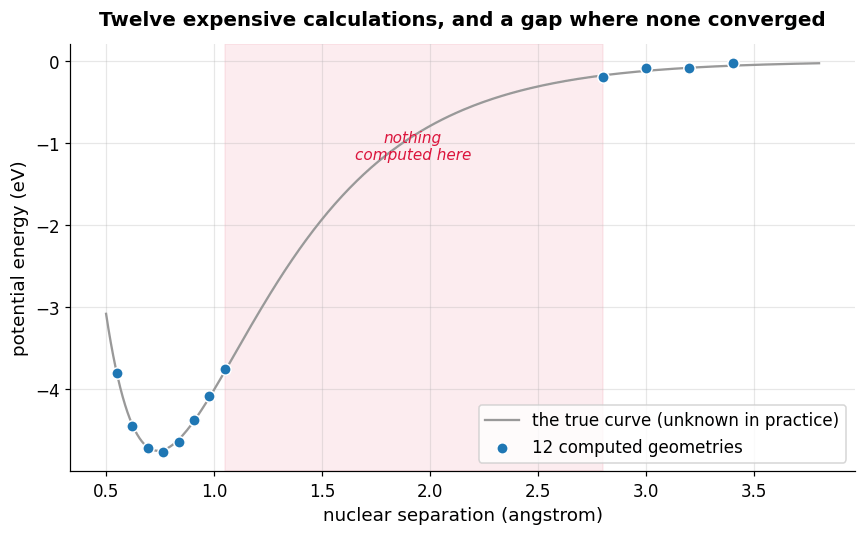

In [ ]:
well_depth, bond_length, steepness = 4.75, 0.74, 1.94       # eV and angstrom, hydrogen-like

def morse(separation):
    """Morse potential energy, in eV, for a nuclear separation in angstrom."""
    return well_depth * (1 - np.exp(-steepness * (separation - bond_length))) ** 2 - well_depth

computed_at = np.concatenate([np.linspace(0.55, 1.05, 8), np.linspace(2.8, 3.4, 4)])
noise_level = 0.02                                          # eV, the calculation's own convergence noise
energies = morse(computed_at) + rng.normal(0, noise_level, computed_at.size)
grid = np.linspace(0.5, 3.8, 300)[:, None]

plt.figure(figsize=(8, 5))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve (unknown in practice)")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="12 computed geometries")
plt.axvspan(1.05, 2.8, color="crimson", alpha=0.08)
plt.text(1.92, -1.2, "nothing\ncomputed here", ha="center", fontsize=10, color="crimson", style="italic")
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("Twelve expensive calculations, and a gap where none converged")
plt.legend(loc="lower right")
plt.show()

The grey curve is drawn only so that the figures can be read; in a real calculation it is exactly
what is not known. Twelve points, a gap, and a question: what is the energy at a separation of
1.5 angstrom?

true well depth            :   4.750 eV
deepest point of the fit   :  -4.781 eV

RMSE where points were computed :   0.043 eV
RMSE inside the gap             :   0.384 eV


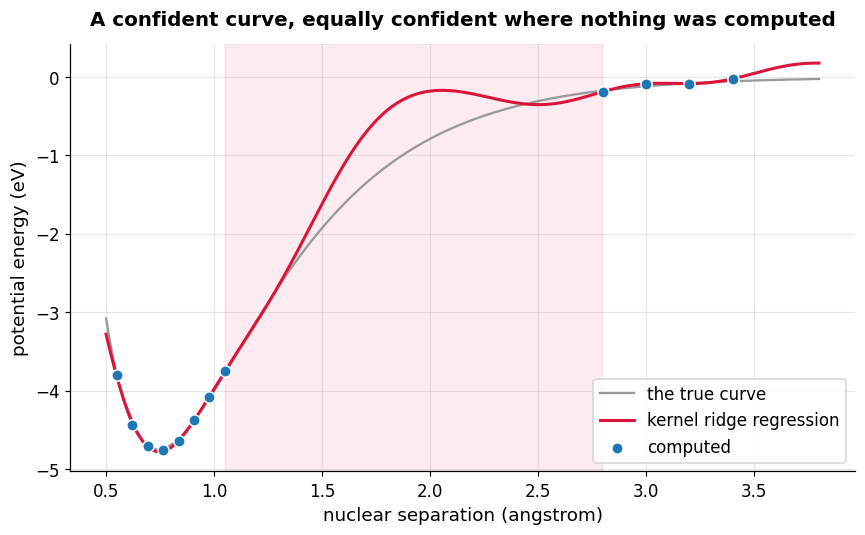

In [ ]:
length_scale = 0.35                                    # angstrom: how far the fit lets a point speak
ridge_penalty = noise_level ** 2

kernel_ridge = KernelRidge(alpha=ridge_penalty, kernel="rbf",
                           gamma=1 / (2 * length_scale ** 2)).fit(computed_at[:, None], energies)
fitted = kernel_ridge.predict(grid)

separations = grid.ravel()
truth = morse(separations)
sampled = separations < 1.1                       # where the eight calculations are
inside_gap = (separations > 1.1) & (separations < 2.8)

def rmse(where):
    """Root mean squared error of the fit against the true curve, over a region of the grid."""
    return np.sqrt(np.mean((fitted[where] - truth[where]) ** 2))

print(f"true well depth            : {-morse(bond_length):>7.3f} eV")
print(f"deepest point of the fit   : {fitted.min():>7.3f} eV")
print(f"\nRMSE where points were computed : {rmse(sampled):>7.3f} eV")
print(f"RMSE inside the gap             : {rmse(inside_gap):>7.3f} eV")

plt.figure(figsize=(8, 5))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve")
plt.plot(grid, fitted, color="crimson", linewidth=2, label="kernel ridge regression")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="computed")
plt.axvspan(1.05, 2.8, color="crimson", alpha=0.08)
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("A confident curve, equally confident where nothing was computed")
plt.legend(loc="lower right")
plt.show()

Read the two errors. Where the calculations sit, the fit tracks the true curve to 0.048 eV.
Across the gap it is out by 0.398 eV — eight times worse, and on the scale of a chemical bond
rather than of a rounding error. The reason is that the RBF kernel has no information there: a sum
of bumps centred on distant points decays towards its mean, so the curve climbs out of the well
far too early.

And **the figure gives no sign of it**. A red curve is drawn across the gap with exactly the same
confidence as across the eight points at the bottom of the well.

That is the honest complaint against every regression method in this course so far. The next
section fixes it.

# 5. Gaussian processes: the same curve, with an error bar

Everything so far in this notebook produced **one** curve. A Gaussian process produces a
*distribution* over curves, and conditions it on the data. What comes back at every input is
therefore not a number but a Gaussian: a mean, which is the prediction, and a variance, which is
the error bar.

This section is the only probability in the notebook. It needs one definition, one matrix and one
identity, in that order.

## 5.1 The definition, and the one object it produces

> A **Gaussian process** is a collection of random variables, any finite number of which have a
> joint Gaussian distribution.

The collection here is the value of the function at every possible input — an infinite family, and
the reason a distribution over functions sounds impossible to write down. The definition is what
makes it possible: you never handle the whole collection. Pick any **finite** set of inputs and the
values there are jointly Gaussian, which is an ordinary multivariate normal with a mean vector and
a covariance matrix and no other content.

A Gaussian has no freedom beyond its first two moments, so two objects fix the process completely:

- a **mean function**, which we set to zero. That is a convention chosen for want of any reason to
  prefer another, not a claim about the data, and the measurements override it immediately.
- a **covariance function** — which is the kernel. This is the whole content of the method:

$$
\operatorname{cov}\big(f(\mathbf{x}),\, f(\mathbf{x}')\big) \;=\; k(\mathbf{x}, \mathbf{x}') ,
\qquad\text{written}\qquad f(\mathbf{x}) \sim \mathcal{GP}\big(0,\, k\big) .
$$

For a physicist that has a shorter name: a **Gaussian random field whose two-point correlation
function you choose**. Choosing the RBF kernel with length scale $\ell$ says that $f(\mathbf{x})$
and $f(\mathbf{x}')$ are strongly correlated when the points are much closer than $\ell$ and
essentially independent when they are much further apart — a statement about how fast the function
is allowed to change, written as a correlation.

### Now apply the definition

The finite set we care about is small: the $n$ inputs where measurements were made, plus the single
point $\mathbf{x}_*$ where a prediction is wanted. Stack the measured values $\mathbf{y}$ with the
unknown value $f_*$. By the definition those $n+1$ numbers are jointly Gaussian, and the kernel
supplies **every entry** of the covariance:

$$
\begin{pmatrix}\mathbf{y}\\[2pt] f_*\end{pmatrix}
\;\sim\;
\mathcal{N}\!\left(\mathbf{0},\;
\begin{pmatrix} K + \sigma_n^2 I & \mathbf{k}_*\\[3pt] \mathbf{k}_*^{\top} & k_{**}\end{pmatrix}\right)
$$

| symbol | what it is | shape |
|---|---|---|
| $\mathbf{y}$ | the $n$ measured values, stacked | $n$ |
| $\mathbf{x}_*$ | the **test point** — wherever a prediction is wanted | — |
| $K$ | the kernel between every pair of *training* inputs, $K_{ij} = k(\mathbf{x}_i,\mathbf{x}_j)$ | $n \times n$ |
| $\mathbf{k}_*$ | the kernel between the *test point* and each training input | $n$ |
| $k_{**}$ | the kernel of the test point with itself; for an RBF this is exactly 1 | scalar |
| $\sigma_n^2$ | the variance of the measurement noise | scalar |

Two notational points, because they trip people. **A subscript $*$ always means "at the test
point"** — never a multiplication. And $\sigma_n^2$ is not a new dial: it is section 1.4's penalty
$\lambda$ under the name probability gives it. It is added to the $K$ block alone, because the
noise is in the measurements and not in the function you are trying to recover.

**Every remaining equation in this section is arithmetic on that one matrix.**

## 5.2 Prediction is conditioning

You know the top block and want the bottom one. That is a conditional distribution, and for a
Gaussian it is a closed form — the single identity this section rests on. For any joint Gaussian
split into two blocks,

$$
\begin{pmatrix}\mathbf{a}\\ \mathbf{b}\end{pmatrix} \sim
\mathcal{N}\!\left(\mathbf{0}, \begin{pmatrix}A & C\\ C^{\top} & B\end{pmatrix}\right)
\qquad\Longrightarrow\qquad
\mathbf{b}\mid\mathbf{a} \;\sim\; \mathcal{N}\big(\,\underbrace{C^{\top}A^{-1}\mathbf{a}}_{\text{mean}},\;\;
\underbrace{B - C^{\top}A^{-1}C}_{\text{covariance}}\big).
$$

In words: conditioning a Gaussian on part of itself leaves another Gaussian, with its mean pulled
toward what was observed and its covariance reduced by a term that **does not contain the
observation**. That is the same arithmetic as *these quantities are correlated, I measured one, so
my belief about the other shifts and tightens*.

Now read off the blocks of section 5.1's matrix — $\mathbf{a} = \mathbf{y}$,
$A = K + \sigma_n^2 I$, $C = \mathbf{k}_*$, $B = k_{**}$ — and substitute:

$$
\boxed{\;\bar{f}_* \;=\; \mathbf{k}_*^{\top}\big(K + \sigma_n^2 I\big)^{-1}\mathbf{y}\;}
\qquad\qquad
\boxed{\;\mathbb{V}[f_*] \;=\; k_{**} \;-\; \mathbf{k}_*^{\top}\big(K + \sigma_n^2 I\big)^{-1}\mathbf{k}_*\;}
$$

That is the whole of Gaussian process regression: one definition, one matrix, one substitution.
Nothing was quoted and nothing else is coming.

Two features of the result decide everything in the rest of the section, and both are now visible
rather than asserted:

- **the mean is linear in $\mathbf{y}$** — it is a fixed row vector times the measurements — which
  is why it will turn out to be kernel ridge regression (section 5.4);
- **the variance contains no $\mathbf{y}$ at all** — only kernel values — which is why the error
  bar cannot depend on what the measurements returned (section 5.5).

The second equation also reads directly: start from $k_{**}$, the variance you would have with no
data, and subtract what the measurements removed. For an RBF kernel $k_{**} = 1$, so the variance
is *one minus what has been learned*, and can never exceed 1.

The cell below does the substitution by hand, on one test point in the middle of the gap, and
checks it against the library.

In [ ]:
test_point = grid.ravel()[np.abs(grid.ravel() - 1.95).argmin()]   # nearest grid point to the
                                                                  # middle of the empty region
rbf = lambda a, b: np.exp(-((a[:, None] - b[None, :]) ** 2) / (2 * length_scale ** 2))

A_block = rbf(computed_at, computed_at) + ridge_penalty * np.eye(computed_at.size)   # K + sigma_n^2 I
k_star = rbf(np.array([test_point]), computed_at).ravel()                            # k_*
k_starstar = 1.0                                                                     # RBF, same point

print(f"the joint covariance is {computed_at.size + 1} x {computed_at.size + 1}, in three blocks:")
print(f"   K + sigma_n^2 I  {str(A_block.shape):>10}      k_*  {str(k_star.shape):>7}"
      f"      k_**  scalar, {k_starstar}")

by_hand_mean = k_star @ np.linalg.solve(A_block, energies)          # C^T A^-1 a
by_hand_var = k_starstar - k_star @ np.linalg.solve(A_block, k_star)  # B - C^T A^-1 C

library = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale), alpha=ridge_penalty,
                                   optimizer=None).fit(computed_at[:, None], energies)
its_mean, its_sd = library.predict([[test_point]], return_std=True)

print(f"\nat {test_point:.2f} angstrom{'':<17}{'mean (eV)':>12}{'sd (eV)':>11}")
print(f"{'the conditioning identity, by hand':<32}{by_hand_mean:>12.6f}{np.sqrt(by_hand_var):>11.6f}")
print(f"{'GaussianProcessRegressor':<32}{its_mean[0]:>12.6f}{its_sd[0]:>11.6f}")
print(f"{'difference':<32}{abs(by_hand_mean - its_mean[0]):>12.1e}"
      f"{abs(np.sqrt(by_hand_var) - its_sd[0]):>11.1e}")

the joint covariance is 13 x 13, in three blocks:
   K + sigma_n^2 I    (12, 12)      k_*    (12,)      k_**  scalar, 1.0

at 1.95 angstrom                    mean (eV)    sd (eV)
the conditioning identity, by hand   -0.209903   0.984579
GaussianProcessRegressor           -0.209903   0.984579
difference                           5.2e-15    2.2e-16


The two agree to the last digit the library prints. Nothing in the section is a black box: the
library assembles the same three blocks and applies the same identity.

## 5.3 What the prior looks like

It is worth seeing the distribution before conditioning, because "a distribution over functions" is
easier to believe once drawn. The cell below samples six functions from the prior — the kernel's
opinion before a single calculation — and six from the posterior, after the twelve calculations
have been conditioned on.

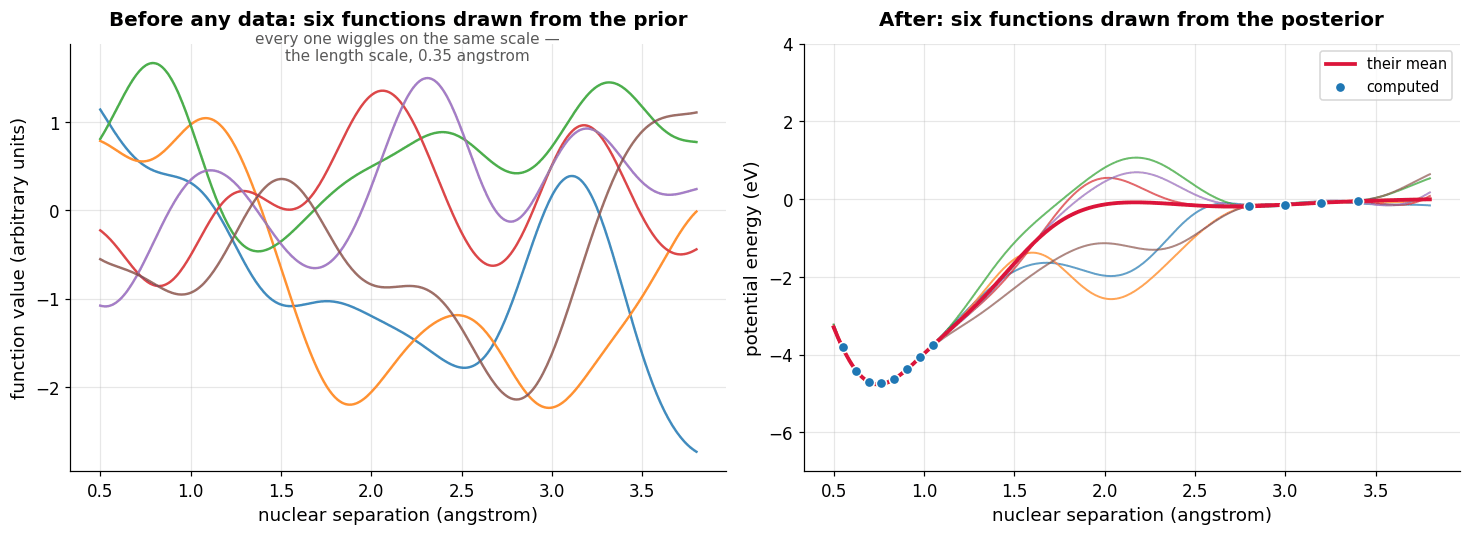

In [ ]:
prior = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale), alpha=ridge_penalty,
                                 optimizer=None)          # never fitted: this is the prior
posterior = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale), alpha=ridge_penalty,
                                     optimizer=None).fit(computed_at[:, None], energies)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for curve in prior.sample_y(grid, n_samples=6, random_state=1).T:
    axes[0].plot(grid, curve, linewidth=1.6, alpha=0.85)
axes[0].set(xlabel="nuclear separation (angstrom)", ylabel="function value (arbitrary units)",
            title="Before any data: six functions drawn from the prior")
axes[0].annotate(f"every one wiggles on the same scale —\nthe length scale, {length_scale} angstrom",
                 xy=(2.2, 1.7), fontsize=10, color="0.35", ha="center")

for curve in posterior.sample_y(grid, n_samples=6, random_state=1).T:
    axes[1].plot(grid, curve, linewidth=1.3, alpha=0.7)
axes[1].plot(grid, posterior.predict(grid), color="crimson", linewidth=2.5, label="their mean")
axes[1].scatter(computed_at, energies, s=45, color="tab:blue", zorder=5, edgecolor="white",
                label="computed")
axes[1].set(xlabel="nuclear separation (angstrom)", ylabel="potential energy (eV)",
            title="After: six functions drawn from the posterior", ylim=(-7, 4))
axes[1].legend(loc="upper right", fontsize=9.5)
plt.show()

The left panel is the prior. None of those six is the Morse curve and none is meant to be; what
they share is a *character*, set by the length scale. They hover around zero because the prior mean
is zero, which section 5.1 flagged as a convention — and the right panel shows how completely the
data overrides it.

The right panel is the posterior: six functions from the same distribution, now restricted to those
consistent with the calculations. Where the points are dense the six are indistinguishable. Across
the gap they fan apart, and **that fan is the error bar** — the band of section 5.6 is this spread,
summarised. The red mean is their average.

## 5.4 The mean is kernel ridge regression

Look again at the boxed mean of section 5.2 and compare it with what section 1.4 produced by
differentiating a penalised least-squares objective and setting the derivative to zero:

$$
\bar{f}_* = \mathbf{k}_*^{\top}\big(K + \sigma_n^2 I\big)^{-1}\mathbf{y}
\qquad\text{against}\qquad
f(\omega_*) = \mathbf{k}_*^{\top}\big(K + \lambda I\big)^{-1}\mathbf{y} .
$$

The same line, with $\lambda$ renamed $\sigma_n^2$. Not an analogue, not a limiting case. A route
through probability that never mentioned a penalty has arrived at the formula a route through
penalties produced, and what one calls a regularisation strength the other calls the variance of
the measurement noise.

Read the shapes and the structure assembles itself: $(K + \sigma_n^2 I)^{-1}\mathbf{y}$ is
$n\times n$ against $n$, giving $n$ numbers — one per training point — which $\mathbf{k}_*^\top$
then contracts to a single prediction. Those $n$ numbers are section 1.7's coefficients,

$$
\boldsymbol{\alpha} = \big(K + \sigma_n^2 I\big)^{-1}\mathbf{y},
\qquad\text{so}\qquad
\bar{f}(\mathbf{x}_*) = \sum_i \alpha_i\, k(\mathbf{x}_i, \mathbf{x}_*),
$$

a weighted sum of one bump per training point — the object section 1.2 drew, and the same
$\boldsymbol{\alpha}$ that `05A` §3.2 wrote for the SVM. The cell below fits both and subtracts.

In [ ]:
process = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale),
                                   alpha=ridge_penalty,      # sigma_n^2, where ridge puts its penalty
                                   optimizer=None).fit(computed_at[:, None], energies)
posterior_mean, posterior_sd = process.predict(grid, return_std=True)

print(f"largest difference between the GP posterior mean and kernel ridge regression: "
      f"{np.abs(posterior_mean - fitted).max():.1e} eV")

largest difference between the GP posterior mean and kernel ridge regression: 1.9e-13 eV


The same curve to thirteen decimal places, and by now that should be expected rather than
surprising. Two derivations with nothing in common but the answer.

So a Gaussian process is not a competitor to kernel ridge regression. For the mean it **is** kernel
ridge regression, reached from probability instead of from a penalty. Everything section 4 fitted,
it fits too — and the second boxed equation is what the extra machinery buys.

## 5.5 The error bar does not depend on what you measured

Section 5.2 already showed why, in one line: $\mathbf{y}$ does not appear in
$\mathbb{V}[f_*]$. The variance is built from the kernel between the test point and the training
inputs, and from nothing else. It is exact, and it is a property of the Gaussian rather than of
machine learning — the conditioning identity subtracts $C^\top A^{-1} C$, in which the observation
$\mathbf{a}$ simply does not occur.

That is easy to mistake for a typographical accident, so the cell below fits a second process to the
same twelve geometries with the energies **replaced by random numbers**, and compares the two error
bars.

In [ ]:
nonsense = rng.normal(0, 3, energies.size)                   # not energies at all
other_process = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale),
                                         alpha=ridge_penalty,
                                         optimizer=None).fit(computed_at[:, None], nonsense)
other_mean, sd_from_nonsense = other_process.predict(grid, return_std=True)

print(f"the two predicted curves differ by up to     : {np.abs(posterior_mean - other_mean).max():>8.3f} eV")
print(f"the two sets of error bars differ by up to   : {np.abs(posterior_sd - sd_from_nonsense).max():>8.1e} eV")

the two predicted curves differ by up to     :   24.077 eV
the two sets of error bars differ by up to   :  0.0e+00 eV


Not small — **exactly zero**. The two models predict entirely different curves and report identical
uncertainty, because the uncertainty answers a different question: not *"how surprising were the
measurements?"* but *"how far is this point from the places I have measured?"*

That is a strength and a limitation in one sentence, and both matter in practice.

- It is a **strength** because the error bar exists before a single measurement is taken. You can
  plan where to put the twelve calculations by evaluating the variance on a grid of candidate
  geometries, and never running any of them.
- It is a **limitation** because the error bar cannot notice that your model is wrong. It subtracts
  from the prior covariance a term for what the measurements told you — but the prior is your own
  choice of kernel and noise level, and a confidently wrong kernel gives confidently narrow bars.

One qualification, because the result is easy to overstate. The variance ignores $\mathbf{y}$ **at
a fixed kernel**, which is what the cell above fitted — `optimizer=None` holds the length scale
where it was put. In normal use the kernel's own parameters are chosen by maximising the marginal
likelihood, which *does* depend on $\mathbf{y}$, so the data re-enters by setting the length scale.
The equation is exact; "a GP's error bars never look at the data" is not.

## 5.6 Where to compute next

at 0.80 angstrom:  predicted  -4.731 eV   +/- 0.012 eV   (true value  -4.693 eV)
at 1.95 angstrom:  predicted  -0.210 eV   +/- 0.985 eV   (true value  -0.865 eV)
at 3.10 angstrom:  predicted  -0.081 eV   +/- 0.021 eV   (true value  -0.097 eV)


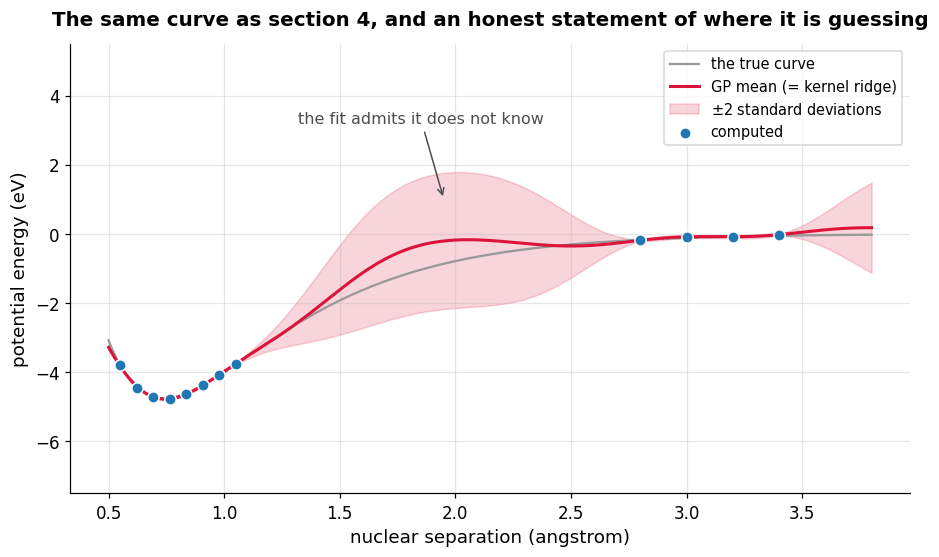

In [ ]:
for separation in [0.80, 1.95, 3.10]:
    nearest = np.abs(grid.ravel() - separation).argmin()
    print(f"at {separation:.2f} angstrom:  predicted {posterior_mean[nearest]:>7.3f} eV"
          f"   +/- {posterior_sd[nearest]:.3f} eV"
          f"   (true value {morse(separation):>7.3f} eV)")

plt.figure(figsize=(8.5, 5.2))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve")
plt.plot(grid, posterior_mean, color="crimson", linewidth=2, label="GP mean (= kernel ridge)")
plt.fill_between(grid.ravel(), posterior_mean - 2 * posterior_sd, posterior_mean + 2 * posterior_sd,
                 color="crimson", alpha=0.18, label="$\\pm 2$ standard deviations")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="computed")
plt.annotate("the fit admits it does not know", xy=(1.95, 1.0), xytext=(1.85, 3.2),
             fontsize=10.5, color="0.3", ha="center",
             arrowprops={"arrowstyle": "->", "color": "0.3"})
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("The same curve as section 4, and an honest statement of where it is guessing")
plt.legend(loc="upper right", fontsize=9.5)
plt.ylim(-7.5, 5.5)
plt.show()

The error bar is 0.012 eV at 0.80 angstrom, where the calculations are packed within a tenth of an
angstrom of each other, and 0.985 eV in the middle of the gap — more than eighty times larger.
That width is doing real work: at 1.95 angstrom the fit predicts $-0.210$ eV where the truth is
$-0.865$ eV, and the $\pm 2$ standard deviation band is wide enough to contain the true curve that
section 4's red line missed in silence. Out at 3.10 angstrom, back among computed points, the bar
collapses to 0.021 eV.

That number is the product. An experimentalist with a fixed budget of measurements, or a
computational chemist with a fixed budget of CPU hours, reads the widest part of the band and puts
the next one there. Done repeatedly, that loop is **Bayesian optimisation**: its acquisition
functions send the next measurement where the model's uncertainty is large, or where its prediction
is promising, or both. This is old and settled practice: it is how expensive computer experiments
have been designed since the late 1980s, and it is where Gaussian processes have always been most
at home.

> A model that reports where it is ignorant is worth more than a slightly more accurate model that
> does not. This is the one place in the course where the uncertainty attaches to the individual
> prediction rather than to the score — map step 9.2.

# 6. What a kernel costs

Every equation in this notebook contains $K$, the matrix of kernel values between **every pair**
of training samples. That matrix has $n^2$ entries and the solutions invert it, so the cost grows
steeply with the sample size. `05A` §3.4 already flagged this for the SVM; the cell below measures
it.

  training events   fit seconds


             1000          0.01
             2000          0.03
             4000          0.13


             8000          0.52


            14265          1.55

over this range the time grows like n^1.8


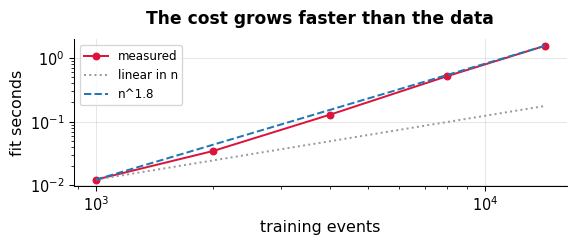

In [ ]:
print(f"{'training events':>17}{'fit seconds':>14}")
timings = []
for size in [1000, 2000, 4000, 8000, 14265]:
    machine = make_pipeline(StandardScaler(), SVC(C=10))
    start = time.time()
    machine.fit(X_train[:size], y_train[:size])
    timings.append(time.time() - start)
    print(f"{size:>17}{timings[-1]:>14.2f}")

growth = np.log(timings[-1] / timings[0]) / np.log(14265 / 1000)
print(f"\nover this range the time grows like n^{growth:.1f}")

sizes = np.array([1000, 2000, 4000, 8000, 14265])
fig, ax = plt.subplots(figsize=(6.2, 2.7), dpi=95)
ax.plot(sizes, timings, marker="o", ms=5, color="crimson", label="measured")
ax.plot(sizes, timings[0] * (sizes / sizes[0]) ** 1.0, ls=":", color="0.6", label="linear in n")
ax.plot(sizes, timings[0] * (sizes / sizes[0]) ** growth, ls="--", color="tab:blue",
        label=f"n^{growth:.1f}")
ax.set(xscale="log", yscale="log", xlabel="training events", ylabel="fit seconds",
       title="The cost grows faster than the data")
ax.legend(fontsize=9)
plt.show()

Fourteen times the data, and far more than fourteen times the work. The cost is well understood:
$O(n^3)$ for the matrix inversion and $O(n^2)$ merely to hold $K$ in memory. Past roughly ten
thousand points an exact Gaussian process stops being practical on an ordinary machine, and `SVC`
carries the same warning in its own documentation — its fit time grows at least quadratically with
the sample size, and it is not the tool for hundreds of thousands of events. The twelve-point
example of section 5 is therefore typical of where GPs are actually used, not a toy reduction of a
big problem.

The standard remedy is to approximate the kernel by an explicit, modest set of features and then
use a *linear* method on them, which is back to `05A`'s cost. scikit-learn ships two:
`Nystroem`, which builds features from a random subset of the training samples, and `RBFSampler`,
which draws random Fourier features instead.

In [ ]:
print(f"{'':44}{'cross-validated ROC AUC':>26}")
for label, machine in [
        ("exact RBF kernel, C = 10", make_pipeline(StandardScaler(), SVC(C=10))),
        ("Nystroem, 300 features, then a linear SVM",
         make_pipeline(StandardScaler(), Nystroem(gamma=0.1, n_components=300, random_state=0),
                       LinearSVC(C=10))),
        ("RBFSampler, 300 features, then a linear SVM",
         make_pipeline(StandardScaler(), RBFSampler(gamma=0.1, n_components=300, random_state=0),
                       LinearSVC(C=10)))]:
    scores = cross_val_score(machine, X_train, y_train, cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{label:44}{scores.mean():>20.4f} +/- {scores.std():.4f}")

                                               cross-validated ROC AUC


exact RBF kernel, C = 10                                  0.9236 +/- 0.0049


Nystroem, 300 features, then a linear SVM                 0.9241 +/- 0.0052


RBFSampler, 300 features, then a linear SVM               0.9185 +/- 0.0051


300 explicit features reproduce the exact kernel's 0.9236 — `Nystroem` at 0.9241 and `RBFSampler`
at 0.9185 — on a model whose cost is now linear in the number of events. On this dataset the
approximation costs nothing measurable; the point of the comparison is that it is available when
$n$ makes the exact kernel impossible.

### If $n$ is genuinely large: where to read next

Explicit features are the first of several answers, and a student who meets a million rows will
want the others. Four that work, in rough order of how much machinery they need.

- **Better landmarks than a random subset.** `Nystroem` picks its landmarks at random from the
  training set. You can instead *learn* a modest number of **inducing points** — pseudo-inputs that
  need not be data at all — by optimisation. Combined with stochastic gradient training this fits
  Gaussian processes to millions of points (Titsias, 2009; Hensman, Fusi & Lawrence, 2013), and it
  is what the dedicated GP libraries implement.
- **Do not approximate at all.** With iterative linear solvers on a GPU, the exact Gaussian process
  of section 5 has been fitted to a million points without any of the shortcuts above (Wang et al.,
  2019). The $O(n^3)$ barrier is a statement about one way of solving the system, not about the
  model.
- **Divide and conquer, for support vector machines.** Train on subsets, pool the **support
  vectors** each one finds, and refit on the pooled set, repeating until it settles. Because only
  the support vectors affect the answer (section 3), almost nothing is lost — the **Cascade SVM**
  (Graf, Cosatto, Bottou, Dourdanovic & Vapnik, 2004) proves that this converges to the global
  optimum of the full problem, and reaches it in two to five passes in practice. Their headline
  demonstration is a million training vectors solved in about a day, no single processor ever
  holding more than 73,000 of them, on a problem where an ordinary SVM had not finished in a week.
- **Approximate kernels beyond the RBF.** `RBFSampler`'s random-features idea extends to other
  stationary kernels, and `scikit-learn`'s kernel-approximation module carries several.

> **One tempting idea that does not work as well as it looks.** Splitting the data into disjoint
> chunks, fitting an independent model to each, and averaging the predictions is the obvious
> parallel scheme, and it has a literature — products of experts, and the Bayesian committee
> machine. It is worth knowing that the naive version is documented to give **inconsistent**
> predictions: with disjoint partitions the combined uncertainty can shrink as more experts are
> added, which is the opposite of what more fragmentation should do. A succession of corrected
> variants exists for exactly that reason. Note the contrast with the Cascade above, which pools
> support vectors and refits rather than averaging separate answers.

# 7. The closing procedure, on a kernel SVM

The seven steps are the same as `03C` §8, `04A` §13, `04B` §12, `04C` §12 and `05A` §7, and this
time only step 4 changes: the grid has two hyperparameters in it rather than one, because section
3.2 showed that $\gamma$ and `C` both control flexibility.

chosen gamma / C          : 0.1 / 100
cross-validated ROC AUC   : 0.9246
test ROC AUC              : 0.9259   95% bootstrap [0.9173, 0.9342]
baseline, linear SVM (05A): 0.8328

the whole grid, as cross-validation saw it:
   gamma 0.1   C 100   ROC AUC 0.9246 +/- 0.0050
   gamma 0.1   C 10    ROC AUC 0.9236 +/- 0.0049
   gamma 0.3   C 10    ROC AUC 0.9199 +/- 0.0037
   gamma 0.3   C 1     ROC AUC 0.9191 +/- 0.0039
   gamma 0.1   C 1     ROC AUC 0.9154 +/- 0.0041
   gamma 0.01  C 100   ROC AUC 0.9140 +/- 0.0042
   gamma 0.3   C 100   ROC AUC 0.9108 +/- 0.0039
   gamma 0.01  C 10    ROC AUC 0.9069 +/- 0.0040
   gamma 0.01  C 1     ROC AUC 0.8949 +/- 0.0036


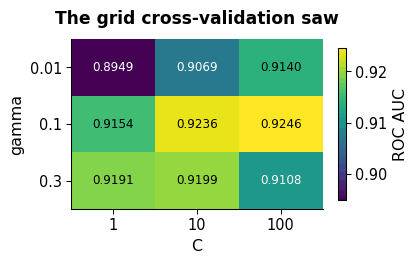

In [ ]:
# 1 (map step 2) — the split made in section 3.2, before anything was looked at.
# 2 (map step 5) — a pipeline, with the scaler inside it: section 3.4.
# 3 (map step 6) — the baseline to beat is 05A's linear SVM, at 0.8328.
# 4 (map step 8) — cross-validate over BOTH dials, on the training part only.
search = GridSearchCV(make_pipeline(StandardScaler(), SVC()),
                      {"svc__gamma": [0.01, 0.1, 0.3], "svc__C": [1, 10, 100]},
                      scoring="roc_auc", cv=folds, n_jobs=-1)
search.fit(X_train, y_train)

# 5 (map step 9) — the test set, once.
test_scores = search.best_estimator_.decision_function(X_test)
test_auc = roc_auc_score(y_test, test_scores)

# 6 (map step 9.2) — an uncertainty on that number, by bootstrapping the test set.
boot_rng = np.random.default_rng(0)          # its own stream: independent of everything above
boot = np.array([roc_auc_score(y_test.to_numpy()[idx], test_scores[idx])
                 for idx in (boot_rng.integers(0, len(y_test), len(y_test)) for _ in range(400))])

# 7 (map step 10) — report it with its limits.
print(f"chosen gamma / C          : {search.best_params_['svc__gamma']} / {search.best_params_['svc__C']}")
print(f"cross-validated ROC AUC   : {search.best_score_:.4f}")
print(f"test ROC AUC              : {test_auc:.4f}   95% bootstrap "
      f"[{np.percentile(boot, 2.5):.4f}, {np.percentile(boot, 97.5):.4f}]")
print(f"baseline, linear SVM (05A): 0.8328")
print(f"\nthe whole grid, as cross-validation saw it:")
order = np.argsort(-search.cv_results_["mean_test_score"])
for i in order:
    p = search.cv_results_["params"][i]
    print(f"   gamma {p['svc__gamma']:<5} C {p['svc__C']:<5} "
          f"ROC AUC {search.cv_results_['mean_test_score'][i]:.4f} "
          f"+/- {search.cv_results_['std_test_score'][i]:.4f}")

gammas, Cs = [0.01, 0.1, 0.3], [1, 10, 100]
heat = np.array([[search.cv_results_["mean_test_score"][
                    next(k for k, q in enumerate(search.cv_results_["params"])
                         if q["svc__gamma"] == g and q["svc__C"] == c)]
                  for c in Cs] for g in gammas])
fig, ax = plt.subplots(figsize=(4.6, 2.9), dpi=95)
image = ax.imshow(heat, cmap="viridis", aspect="auto")
ax.set(xticks=range(3), xticklabels=Cs, yticks=range(3), yticklabels=gammas,
       xlabel="C", ylabel="gamma", title="The grid cross-validation saw")
for r in range(3):
    for c in range(3):
        ax.text(c, r, f"{heat[r, c]:.4f}", ha="center", va="center", fontsize=9,
                color="white" if heat[r, c] < heat.max() - 0.012 else "black")
ax.grid(visible=False)
fig.colorbar(image, ax=ax, label="ROC AUC", shrink=0.9)
plt.show()

Read the grid, not only the winner. The scores are close across a broad region and fall away at
the corners, which is the usual shape and the reason a two-dimensional search is worth its cost
here where `05A`'s one-dimensional sweep over `C` was flat.

The reported number carries the same limits as every other in the course: it is an ROC AUC on
*these* simulated showers, from a single test split, and the bootstrap interval measures only the
test set's size — not the simulation's fidelity to a real telescope, which `05A` §6 raised and no
resampling can address.

# 8. Common pitfalls

**Leaving the features unscaled.** The RBF kernel is a distance in disguise, and section 3.4 lost
0.04 of ROC AUC to a missing `StandardScaler` with no error and no warning.

**Tuning $\gamma$ on the training score.** It rises monotonically to 1.0000 and means nothing
(section 3.2). Only the cross-validated column turns around, and it turns around well before the
training score flattens.

**Tuning $\gamma$ and `C` separately.** They both control flexibility and they interact, so a
sweep over one at a fixed value of the other can miss the good region entirely. Section 7 searches
the pair.

**Reading a kernel ridge curve as though it were supported everywhere.** Section 4 drew a
confident line through a region containing no data. Nothing in the output distinguished it from
the part of the curve that was fitted.

**Reading a Gaussian process error bar as a test of the model.** It does not depend on the
measured values at all (section 5.3), so it cannot tell you the kernel was a poor choice. It
reports distance from your measurements, nothing more.

**Reaching for an exact kernel on a large sample.** The fit grew faster than $n^2$ in section 6.
Past a few tens of thousands of samples, use `Nystroem` or `RBFSampler`, or a different family.

**Expecting a kernel to cope with irrelevant features.** This is the family's most firmly
established weakness, and the early claim that kernels finesse the curse of dimensionality is
simply false. In a standard textbook simulation, adding six columns of pure
noise to a four-feature problem moves a degree-2 polynomial SVM's error from 0.078 to 0.152, while
methods able to concentrate on a subspace barely move.
The reason is the one `05A` §1 gave: the kernel is a distance over *all* the features, and it
cannot decide to look at a subspace. `05A` §4.2 measured the same effect on nearest neighbours, and
it is why the optional notebook `X1` lists distance-based models as the ones for which feature
selection matters most.

**Treating the kernel as a universal upgrade.** On the telescope events it bought 0.09 of ROC AUC;
broad benchmarks still put random forests ahead of RBF SVMs on average, and `04A` §11.1's
advantage — a tree needs no scaling and takes mixed feature types as they come — is untouched by
any of this.

# 9. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — The degree-3 kernel</b><br>
Section 2.1 verified $\boldsymbol{\phi}(\mathbf{x}) \cdot \boldsymbol{\phi}(\mathbf{x}') = (1 +
\mathbf{x}\cdot\mathbf{x}')^2$ for two features.
<br><br>
1. How many terms does a degree-3 polynomial expansion of two features have? Write them out.<br>
2. Use <code>sklearn.preprocessing.PolynomialFeatures(degree=3)</code> to build the expansion for two
random samples, and take the dot product of the results.<br>
3. Compare it with $(1 + \mathbf{x}\cdot\mathbf{x}')^3$. They will <em>not</em> be equal. Look at the
coefficients in section 2.1's <code>expansion</code> and work out what <code>PolynomialFeatures</code>
would have to multiply each term by for them to agree.<br>
4. What does this tell you about which expansion a polynomial kernel actually corresponds to?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — How far does a training point reach?</b><br>
Section 2.3 said that $\gamma$ sets the reach of each training sample.
<br><br>
1. Fit <code>SVC(gamma=g)</code> to the rings of section 1 for $g$ = 0.1, 1, 10 and 100.<br>
2. For each, draw the decision boundary over the mesh as section 3.1 does.<br>
3. Report the number of support vectors in each case, and the training accuracy.<br>
4. At $g = 100$ the training accuracy is excellent and the boundary is a collection of islands.
Explain what the model has learned, in terms of the figure in section 3.2, and say which value of
$k$ in <code>05A</code> section 2.2 it resembles.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Where would you compute next?</b><br>
Section 5.3 read the error bar off a Gaussian process fitted to twelve geometries.
<br><br>
1. Refit the process of section 5 using only the <em>eight</em> points below 1.1 angstrom.<br>
2. Plot the mean and the $\pm 2$ standard deviation band over the same grid. Where is the band
widest now?<br>
3. Add one calculation at the separation where the band is widest, refit, and report how much the
widest band has narrowed.<br>
4. Repeat step 3 twice more. Then answer: would choosing the three extra geometries on an evenly
spaced grid have done better or worse, and how would you decide that fairly?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 4 — Is the kernel worth it on your own data?</b><br>
Take any dataset from an earlier notebook with continuous features — the California housing data of
<code>04C</code> section 5, or the diabetes cohort of <code>02A</code> section 8.
<br><br>
1. Cross-validate a <code>Ridge</code> model and a <code>KernelRidge(kernel="rbf")</code> on it, both
inside a <code>StandardScaler</code>, tuning <code>alpha</code> and <code>gamma</code>.<br>
2. Record the fit time of each.<br>
3. Compare both with the gradient boosting result the earlier notebook reported.<br>
4. On the evidence of your three numbers, and of section 6's timings, when would you choose the
kernel method for this dataset? Give a condition, not a preference.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- **A model is only as good as its basis.** Powers of the input reached 0.042 at degree 13 and then
  fell apart, missing by 30 at degree 25 with the largest coefficient at $3\times10^{11}$ by degree
  31 — and nothing in the data points to 13. In more than one dimension the basis also explodes:
  ten features give 66 quadratic terms and 286 cubic ones.
- **A basis fixed before seeing the data is mostly wasted.** On the telescope's ten features, a grid
  of five bins per feature has 9.8 million cells and the 14,265 training events visit 2,235 of them
  — 0.02% — while 90% of unseen test events land in those same cells. - **Putting one basis function at each measurement** removes
  the choice of degree. It fitted the same resonance to 0.012 — three times better than the best
  polynomial — with no search. - **That basis has as many coefficients as measurements**, so it has
  exactly enough freedom to chase every reading: with no penalty it missed the truth by 490 on a curve of height 1, using weights of
  order $10^{14}$. - **The penalty is $\boldsymbol{\alpha}^\top K\boldsymbol{\alpha}$, not $\sum_i
  \alpha_i^2$**, because the basis functions are not orthonormal and $K$ is their matrix of inner
  products. With bumps of one linewidth the two agree; with bumps of five the naive one is twice as
  bad. - **The metric has to charge wiggles, not size.** Three sines of equal amplitude have identical
  $\int f^2$, 0.5000 apiece, while $\int (df/dx)^2$ runs from 19.7 to 7896.1. - **The overlaps
  come for free.** Computed as integrals they give a *different* matrix — 0.76017 at one
  linewidth against $K$'s 0.36788, the integral of two Gaussians being $\sqrt{2}$ wider — and the
  reproducing property is what lets $K$ be the design matrix and the metric at once. -
  **Standardising equalises size, not roughness.** Standardised $x^3$ is 1.800 times rougher than
  $x$ and $x^5$ is 2.778 times, so $\sum_j \alpha_j^2$ on a hand-built polynomial basis is an
  amplitude prior, not a smoothness one. - The **kernel trick** replaces every dot product between samples by a kernel. For the
  degree-2 polynomial kernel, $(1 + \mathbf{x}\cdot\mathbf{x}')^2$ and the dot product of two
  explicit six-dimensional expansions agree to machine precision — one of them builds the expansion
  and the other never does. - A valid kernel is **symmetric and positive semi-definite**; those are
  exactly the functions that correspond to a dot product in some feature space. - The **RBF
  kernel** $\exp(-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2)$ turns `05A`'s distance into a
  similarity. On the rings it scored 0.987 against 0.550 for the same machine with a linear kernel,
  with no expansion built and nothing said about circles. - $\gamma$ is a **flexibility dial** and
  it overfits hard: on 4,000 telescope events the training ROC AUC climbed to 1.0000 while the
  cross-validated score peaked at 0.9105 and fell to 0.8142. - On the full telescope data the
  kernel moved the SVM from **0.8328 to 0.9236**, past nearest neighbours and within 0.012 of the
  random forest — `04A` §11.2's promise, and confirmation that `05A`'s diagnosis of a wrong-shaped
  boundary was right. - **A kernel built from a distance needs scaled features**: 0.8835 raw
  against 0.9236 standardised, with no warning in between. - **Kernel ridge regression** is the
  same substitution applied to `03C`'s ridge. On the Morse curve it tracked the truth to 0.048 eV
  where calculations existed and was out by 0.398 eV across the gap, with nothing in the figure to
  distinguish the two. - **A Gaussian process posterior mean *is* kernel ridge regression** — the
  two agreed to $10^{-13}$ eV — with the noise variance $\sigma_n^2$ standing where the ridge
  penalty stands. - **The GP's error bar does not depend on the measured values.** Replacing the
  energies with random numbers changed it by exactly zero. It reports distance from your
  measurements: 0.012 eV among the computed points, 0.985 eV in the middle of the gap. - Kernels
  cost $O(n^2)$ memory and up to $O(n^3)$ time. `Nystroem` with 300 features reproduced the exact
  kernel's 0.9236 at 0.9241, on a model that is linear in $n$.

# Optional preparation for the next notebook

Before `05C`, students should be comfortable with:

- the RBF kernel as a **neighbourhood**: samples within roughly $1/\sqrt{\gamma}$ of each other are
  similar, and everything beyond that is effectively invisible;
- the Euclidean distance and the need to scale before using one (`05A` §1, section 3.4 here);
- reading a two-dimensional scatter plot of labelled points, as in section 1.

`05C` keeps the distance and throws away the labels. **Clustering** asks what structure the samples
have when nothing says which class they belong to — $k$-means, hierarchical clustering, and DBSCAN,
which grows a cluster by joining samples that lie within a radius $\varepsilon$ of one another.
That $\varepsilon$-ball and this notebook's RBF kernel are the same neighbourhood idea used for two
different purposes, which is why Class 5 is one hour of supervised learning from distances followed
by one hour of unsupervised learning from the same distances.